In [ ]:
#### CUDA CONTROL######

In [1]:
import torch, platform, os

print("Python:", platform.python_version())
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version (torch):", torch.version.cuda)
    print("GPU count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}:", torch.cuda.get_device_name(i))
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

# Basit test: GPU'da tensor işlemi
x = torch.randn(1024, 1024, device=device)
y = x @ x
print("Matmul OK. y mean:", y.mean().item())


Python: 3.11.5
Platform: macOS-26.5-arm64-arm-64bit
PyTorch: 2.1.2
CUDA available: False
Using device: cpu
Matmul OK. y mean: 0.020961623638868332


In [3]:
######## FolDER CONTROLT#####

In [4]:
from pathlib import Path

COCO_ROOT = Path(r"C:\Users\fatma\Desktop\implant\coco_dataset")  # burayı değiştir

for p in COCO_ROOT.iterdir():
    print(p.name)
def count_images(split_dir):
    exts = {".jpg",".jpeg",".png",".bmp",".tif",".tiff",".webp"}
    return sum(1 for p in split_dir.rglob("*") if p.suffix.lower() in exts)

for split in ["train", "valid", "val", "test"]:
    d = COCO_ROOT / split
    if d.exists():
        print(f"{split}: {count_images(d)} images")


README.dataset.txt
README.roboflow.txt
test
train
valid
train: 1754 images
valid: 201 images
test: 109 images


### ANNOTATION KISMININ VARLIĞI KONTROL####

In [5]:
from pathlib import Path

COCO_ROOT = Path(r"C:\Users\fatma\Desktop\implant\coco_dataset")

for split in ["train", "valid", "test"]:
    d = COCO_ROOT / split
    print("\nSPLIT:", split, "| exists:", d.exists())
    if d.exists():
        jsons = list(d.glob("*.json"))
        print(" JSON files:", [p.name for p in jsons])
        # birkaç görsel örneği
        imgs = list(d.glob("*.jpg"))[:3] + list(d.glob("*.png"))[:3]
        print(" sample images:", [p.name for p in imgs[:6]])



SPLIT: train | exists: True
 JSON files: ['_annotations.coco.json']
 sample images: ['bego-0_jpg.rf.3c722e8fe0716ea1814323e54480759c.jpg', 'bego-0_jpg.rf.61c2072c8a808031c3590b4ab22dae0b.jpg', 'bego-0_jpg.rf.c4a2c27af678cff168ff1f3c7de81b24.jpg']

SPLIT: valid | exists: True
 JSON files: ['_annotations.coco.json']
 sample images: ['bego-17_jpg.rf.37e1ea5cf9434ad1ae6f2c12afc86ae8.jpg', 'bego-29_jpg.rf.4c20efdaf339d280139f70405d68ae64.jpg', 'bego-34_jpg.rf.85aff5013a81bca17c406092d9bef629.jpg']

SPLIT: test | exists: True
 JSON files: ['_annotations.coco.json']
 sample images: ['bego-18_jpg.rf.fcc9da78239aba0792090120ae7c5188.jpg', 'bego-33_jpg.rf.338f45f6d3ec9d86a0246498b098fdfb.jpg', 'bego-38_jpg.rf.966b6fb0b17ed5448fec6579a96e409b.jpg']


In [6]:
###COCO VERİLERİNE GÖRE ROILERİN ÇIAKRILMASI VE DOSYA İSİMLERİNE GÖRE MARKA KLASÖRLERİNE ROİ GÖRÜNTÜLERİNİNAKTARILMASI####

In [7]:
import json
import cv2
import pandas as pd
from pathlib import Path
import re

COCO_ROOT = Path(r"C:\Users\fatma\Desktop\implant\coco_dataset")
OUT_ROOT  = Path(r"C:\Users\fatma\Desktop\implant\roi_brands")

PAD = 8
MIN_W, MIN_H = 20, 20
BBOX_MODE = "all"   # "largest" da olabilir

SPLITS = ["train", "valid", "test"]

# Marka anahtar kelimeleri (dosya adından çıkarım)
BRAND_PATTERNS = {
    "bego":  re.compile(r"\bbego\b", re.IGNORECASE),
    "bicon": re.compile(r"\bbicon\b", re.IGNORECASE),
    "iti":   re.compile(r"\biti\b", re.IGNORECASE),
}

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def clip_bbox(x, y, w, h, W, H, pad=0):
    x1 = max(int(x - pad), 0)
    y1 = max(int(y - pad), 0)
    x2 = min(int(x + w + pad), W)
    y2 = min(int(y + h + pad), H)
    return x1, y1, x2, y2

def infer_brand_from_filename(file_name: str) -> str:
    base = Path(file_name).stem.lower()
    for brand, pat in BRAND_PATTERNS.items():
        if pat.search(base):
            return brand
    # bazı durumlarda "bego-" gibi tireli gelir; \b yakalayamazsa manuel yakala:
    for brand in BRAND_PATTERNS.keys():
        if base.startswith(brand + "-") or base.startswith(brand + "_") or (brand in base):
            return brand
    return "unknown"

def find_image_path(split_dir: Path, file_name: str) -> Path:
    # Roboflow genelde aynı klasörde
    p = split_dir / file_name
    if p.exists():
        return p
    # basename ile ara
    base = Path(file_name).name
    cand = list(split_dir.glob(base))
    return cand[0] if cand else None

def coco_split_to_roi_brands(split: str):
    split_dir = COCO_ROOT / split
    coco_json = split_dir / "_annotations.coco.json"
    if not coco_json.exists():
        print(f"❌ {split}: _annotations.coco.json yok")
        return

    with open(coco_json, "r", encoding="utf-8") as f:
        coco = json.load(f)

    img_id_to_file = {im["id"]: im["file_name"] for im in coco["images"]}

    anns_by_img = {}
    for ann in coco["annotations"]:
        anns_by_img.setdefault(ann["image_id"], []).append(ann)

    # split output klasörleri
    for b in list(BRAND_PATTERNS.keys()) + ["unknown"]:
        ensure_dir(OUT_ROOT / split / b)

    meta = []
    crop_count, miss_img, small, empty_crop = 0, 0, 0, 0

    for img_id, file_name in img_id_to_file.items():
        img_path = find_image_path(split_dir, file_name)
        if img_path is None or not img_path.exists():
            miss_img += 1
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            miss_img += 1
            continue

        H, W = img.shape[:2]
        anns = anns_by_img.get(img_id, [])
        if not anns:
            continue

        if BBOX_MODE == "largest":
            anns = [max(anns, key=lambda a: a["bbox"][2] * a["bbox"][3])]

        brand = infer_brand_from_filename(file_name)

        for ann in anns:
            x, y, w, h = ann["bbox"]
            if w < MIN_W or h < MIN_H:
                small += 1
                continue

            x1, y1, x2, y2 = clip_bbox(x, y, w, h, W, H, pad=PAD)
            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                empty_crop += 1
                continue

            stem = Path(file_name).stem
            out_name = f"{stem}__img{img_id}__ann{ann['id']}__{x1}_{y1}_{x2}_{y2}.jpg"
            out_path = OUT_ROOT / split / brand / out_name

            cv2.imwrite(str(out_path), crop)
            crop_count += 1

            meta.append({
                "split": split,
                "brand_inferred": brand,
                "src_image": str(img_path),
                "file_name": file_name,
                "image_id": img_id,
                "ann_id": ann["id"],
                "bbox_x": x, "bbox_y": y, "bbox_w": w, "bbox_h": h,
                "crop_path": str(out_path)
            })

    meta_path = OUT_ROOT / split / "roi_brand_metadata.csv"
    pd.DataFrame(meta).to_csv(meta_path, index=False)

    print(f"✅ {split}: crops={crop_count} | missing_images={miss_img} | skipped_small={small} | empty_crop={empty_crop}")
    print("Saved:", meta_path)

# RUN
ensure_dir(OUT_ROOT)
for s in SPLITS:
    coco_split_to_roi_brands(s)

print("\nDONE:", OUT_ROOT)


✅ train: crops=2297 | missing_images=0 | skipped_small=505 | empty_crop=0
Saved: C:\Users\fatma\Desktop\implant\roi_brands\train\roi_brand_metadata.csv
✅ valid: crops=256 | missing_images=0 | skipped_small=65 | empty_crop=0
Saved: C:\Users\fatma\Desktop\implant\roi_brands\valid\roi_brand_metadata.csv
✅ test: crops=135 | missing_images=0 | skipped_small=18 | empty_crop=0
Saved: C:\Users\fatma\Desktop\implant\roi_brands\test\roi_brand_metadata.csv

DONE: C:\Users\fatma\Desktop\implant\roi_brands


### OLUŞTURULAN DOSYA METADATALARININ KONTROLU####

In [8]:
from pathlib import Path

OUT_ROOT  = Path(r"C:\Users\fatma\Desktop\implant\roi_brands")

def count_jpg(p: Path):
    return sum(1 for _ in p.rglob("*.jpg"))

for split in ["train","valid","test"]:
    print("\n", split)
    for brand in ["bego","bicon","iti","unknown"]:
        d = OUT_ROOT / split / brand
        if d.exists():
            print("  ", brand, ":", count_jpg(d))



 train
   bego : 155
   bicon : 1244
   iti : 898
   unknown : 0

 valid
   bego : 12
   bicon : 146
   iti : 98
   unknown : 0

 test
   bego : 4
   bicon : 80
   iti : 51
   unknown : 0


In [9]:
#### GRUP ID LER OLUŞTURTULACAK BÖYLELİKLE RF Lİ OLANLARDAN KAYNAKLANACAK VERİ SIZINTISININ ÖNÜNE GEÇMEK ###

In [10]:
from pathlib import Path
import pandas as pd
import re

ROI_ROOT = Path(r"C:\Users\fatma\Desktop\implant\roi_brands")  # senin ürettiğin klasör
BRANDS = ["bego","bicon","iti"]

# group_id çıkarımı:
# örnek dosya: bego-0_jpg.rf.3c722e8fe0716ea1814323e54480759c__img...jpg
# group_id: bego-0_jpg
def extract_group_id(filename: str) -> str:
    base = Path(filename).name
    # __img... öncesini al
    left = base.split("__img")[0]
    # .rf.<hash> varsa onu kırp
    left = re.sub(r"\.rf\.[A-Za-z0-9]+", "", left)
    return left  # ör: bego-0_jpg

rows = []
for split in ["train","valid","test"]:
    for brand in BRANDS:
        d = ROI_ROOT / split / brand
        if not d.exists():
            continue
        for p in d.glob("*.jpg"):
            gid = extract_group_id(p.name)
            rows.append({
                "path": str(p),
                "brand": brand,
                "y": BRANDS.index(brand),
                "orig_split": split,
                "group_id": gid
            })

df = pd.DataFrame(rows)
print("Total ROI:", len(df))
print(df["brand"].value_counts())
print("Unique groups:", df["group_id"].nunique())
df.head()


Total ROI: 2688
brand
bicon    1470
iti      1047
bego      171
Name: count, dtype: int64
Unique groups: 934


,path,brand,y,orig_split,group_id
0,C:\Users\fatma\Desktop\implant\roi_brands\trai...,bego,0,train,bego-0_jpg
1,C:\Users\fatma\Desktop\implant\roi_brands\trai...,bego,0,train,bego-0_jpg
2,C:\Users\fatma\Desktop\implant\roi_brands\trai...,bego,0,train,bego-0_jpg
3,C:\Users\fatma\Desktop\implant\roi_brands\trai...,bego,0,train,bego-10_jpg
4,C:\Users\fatma\Desktop\implant\roi_brands\trai...,bego,0,train,bego-10_jpg


In [12]:
leak = (df.groupby("group_id")["orig_split"].nunique() > 1).sum()
print("Groups appearing in >1 original split:", leak)

# Örnek birkaç sızan grup:
leaky_groups = df.groupby("group_id")["orig_split"].nunique()
leaky_groups = leaky_groups[leaky_groups > 1].index.tolist()[:10]
df[df["group_id"].isin(leaky_groups)][["group_id","brand","orig_split"]].sort_values(["group_id","orig_split"]).head(30)


Groups appearing in >1 original split: 0


,group_id,brand,orig_split


In [ ]:
###import##

In [13]:
# Core
import os, re, time, random
from pathlib import Path

# Numerical & Data
import numpy as np
import pandas as pd

# CV
import cv2

# Torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

# AMP
from torch.cuda.amp import autocast, GradScaler

# Sklearn
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2


C:\Users\fatma\anaconda3\envs\torch_gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
###device/seed###

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)


Device: cuda
GPU: NVIDIA GeForce RTX 3090


In [ ]:
##ALBUMENTATIONS TRANSFORMLARI##

In [15]:
IMG_SIZE = 224

train_tf = A.Compose([
    A.RandomResizedCrop(
        size=(IMG_SIZE, IMG_SIZE),
        scale=(0.85, 1.0)
    ),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussianBlur(p=0.1),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

test_tf = A.Compose([
    A.Resize(int(IMG_SIZE * 1.15), int(IMG_SIZE * 1.15)),
    A.CenterCrop(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

print("Albumentations transforms fixed and ready")


Albumentations transforms fixed and ready


In [16]:
###4️⃣ DATASET CLASS (DFImageDataset)##

In [17]:
class DFImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.loc[idx, "path"]
        y = int(self.df.loc[idx, "y"])

        img = cv2.imread(path)
        if img is None:
            raise RuntimeError(f"Image not found: {path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)["image"]

        return img, y


In [18]:
### DATAFRAME OLUŞTUR (ROI → df)####3

In [19]:
ROI_ROOT = Path(r"C:\Users\fatma\Desktop\implant\roi_brands")
BRANDS = ["bego", "bicon", "iti"]

def extract_group_id(filename: str) -> str:
    base = Path(filename).name
    left = base.split("__img")[0]
    left = re.sub(r"\.rf\.[A-Za-z0-9]+", "", left)
    return left

rows = []
for orig_split in ["train","valid","test"]:
    for brand in BRANDS:
        d = ROI_ROOT / orig_split / brand
        if not d.exists():
            continue
        for p in d.glob("*.jpg"):
            rows.append({
                "path": str(p),
                "brand": brand,
                "y": BRANDS.index(brand),
                "group_id": extract_group_id(p.name)
            })

df = pd.DataFrame(rows)

print("Total ROI:", len(df))
print(df["brand"].value_counts())
print("Unique groups:", df["group_id"].nunique())


Total ROI: 2688
brand
bicon    1470
iti      1047
bego      171
Name: count, dtype: int64
Unique groups: 934


In [20]:
###GROUP-AWARE 80/20 TRAIN–TEST SPLIT###

In [21]:
TEST_SIZE = 0.2

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=SEED
)

train_idx, test_idx = next(
    gss.split(df, y=df["y"], groups=df["group_id"])
)

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size :", len(test_df))
print("Group overlap:",
      len(set(train_df["group_id"]) & set(test_df["group_id"])))


Train size: 2149
Test size : 539
Group overlap: 0


In [22]:
###CLASS-WEIGHTED LOSS###

In [23]:
counts = train_df["y"].value_counts().sort_index().values
weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)

class_weights = torch.tensor(
    weights, dtype=torch.float32, device=device
)

criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Class weights:", class_weights)


Class weights: tensor([2.4202, 0.2398, 0.3400], device='cuda:0')


In [24]:
###MODEL (ResNet50)EVALUATION FUNCTION###

In [29]:
from pathlib import Path

RUNS = Path("./runs_grouped_80_20")
MODELS_DIR  = RUNS / "models"
RESULTS_DIR = RUNS / "results"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best = None
        self.bad = 0

    def step(self, metric):
        if self.best is None or metric > self.best + self.min_delta:
            self.best = metric
            self.bad = 0
            return False
        self.bad += 1
        return self.bad >= self.patience


In [30]:
import torch

scaler = torch.amp.GradScaler('cuda', enabled=(device.type == "cuda"))

def train_one_fold_amp(
    fold, tr_df, va_df,
    epochs=50, batch_size=32, lr=1e-4,
    patience=7
):
    train_ds = DFImageDataset(tr_df, transform=train_tf)
    val_ds   = DFImageDataset(va_df, transform=test_tf)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=0, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=64, shuffle=False,
        num_workers=0, pin_memory=True
    )

    model = get_model_resnet50(NUM_CLASSES)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=2, factor=0.5
    )

    early = EarlyStopping(patience=patience)
    best_path = MODELS_DIR / f"resnet50_amp_fold{fold}_best.pt"

    history = []
    best_f1 = -1.0

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        total_loss, n = 0.0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * x.size(0)
            n += x.size(0)

        train_loss = total_loss / max(n, 1)
        val_loss, val_f1, y_true, y_pred = evaluate(model, val_loader)

        scheduler.step(val_f1)

        history.append({
            "fold": fold,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_macro_f1": float(val_f1),
            "lr": optimizer.param_groups[0]["lr"],
            "sec": round(time.time() - t0, 2),
            "train_size": len(tr_df),
            "val_size": len(va_df)
        })

        print(
            f"Fold {fold} | Epoch {epoch:02d} | "
            f"train_loss {train_loss:.4f} | val_macroF1 {val_f1:.4f}"
        )

        # best checkpoint
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), best_path)

            # val confusion matrix + report (best epoch için)
            cm = confusion_matrix(y_true, y_pred)
            cm_df = pd.DataFrame(cm, index=BRANDS, columns=BRANDS)
            cm_df.to_csv(RESULTS_DIR / f"fold{fold}_best_val_cm.csv")

            rep = classification_report(y_true, y_pred, target_names=BRANDS, output_dict=True)
            pd.DataFrame(rep).T.to_csv(RESULTS_DIR / f"fold{fold}_best_val_report.csv")

        # early stop
        if early.step(val_f1):
            print(f"Early stopping on fold {fold} at epoch {epoch}. Best val_macroF1={best_f1:.4f}")
            break

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(RESULTS_DIR / f"fold{fold}_history.csv", index=False)
    return str(best_path), hist_df


In [31]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

X = train_df.index.values
y = train_df["y"].values
groups = train_df["group_id"].values

all_hist = []
best_paths = []

for fold, (tr_i, va_i) in enumerate(sgkf.split(X, y=y, groups=groups), start=1):
    tr = train_df.iloc[tr_i].reset_index(drop=True)
    va = train_df.iloc[va_i].reset_index(drop=True)

    best_path, hist_df = train_one_fold_amp(fold, tr, va, epochs=25, batch_size=32, lr=1e-4, patience=7)
    best_paths.append(best_path)
    all_hist.append(hist_df)

log_df = pd.concat(all_hist, ignore_index=True)
log_df.to_csv(RESULTS_DIR / "resnet50_amp_kfold_log.csv", index=False)

print("Saved:", RESULTS_DIR / "resnet50_amp_kfold_log.csv")
print("Best paths:", best_paths)


Fold 1 | Epoch 01 | train_loss 1.0036 | val_macroF1 0.3563
Fold 1 | Epoch 02 | train_loss 0.5800 | val_macroF1 0.5759
Fold 1 | Epoch 03 | train_loss 0.3899 | val_macroF1 0.7156
Fold 1 | Epoch 04 | train_loss 0.2258 | val_macroF1 0.7585
Fold 1 | Epoch 05 | train_loss 0.1928 | val_macroF1 0.8372
Fold 1 | Epoch 06 | train_loss 0.1267 | val_macroF1 0.9153
Fold 1 | Epoch 07 | train_loss 0.0917 | val_macroF1 0.8768
Fold 1 | Epoch 08 | train_loss 0.1083 | val_macroF1 0.8382
Fold 1 | Epoch 09 | train_loss 0.0673 | val_macroF1 0.8374
Fold 1 | Epoch 10 | train_loss 0.0355 | val_macroF1 0.8798
Fold 1 | Epoch 11 | train_loss 0.0352 | val_macroF1 0.8299
Fold 1 | Epoch 12 | train_loss 0.0228 | val_macroF1 0.8550
Fold 1 | Epoch 13 | train_loss 0.0205 | val_macroF1 0.8643
Early stopping on fold 1 at epoch 13. Best val_macroF1=0.9153
Fold 2 | Epoch 01 | train_loss 0.9425 | val_macroF1 0.3749
Fold 2 | Epoch 02 | train_loss 0.5093 | val_macroF1 0.6545
Fold 2 | Epoch 03 | train_loss 0.3223 | val_macroF1 0

In [ ]:
###resnet-50 test işlemi####

In [36]:
needed = ["train_df","test_df","BRANDS","NUM_CLASSES","device","criterion","evaluate","get_model_resnet50","DFImageDataset","test_tf","SEED"]
missing = [x for x in needed if x not in globals()]
print("Missing:", missing)
assert len(missing)==0, f"Eksik değişken/fonksiyonlar var: {missing}"
from pathlib import Path
import pandas as pd
import numpy as np
import re
import torch

RUNS = Path("./runs_grouped_80_20")
MODELS_DIR  = RUNS / "models"
RESULTS_DIR = RUNS / "results"

print("MODELS_DIR exists:", MODELS_DIR.exists(), MODELS_DIR)
print("RESULTS_DIR exists:", RESULTS_DIR.exists(), RESULTS_DIR)
fold_summ = []

hist_files = sorted(RESULTS_DIR.glob("fold*_history.csv"))
assert len(hist_files) > 0, "fold*_history.csv bulunamadı. Eğitim logları results klasöründe mi?"

for hist_path in hist_files:
    fold = int(re.findall(r"fold(\d+)_history", hist_path.name)[0])
    h = pd.read_csv(hist_path)
    best_row = h.loc[h["val_macro_f1"].idxmax()]
    fold_summ.append({
        "fold": fold,
        "best_epoch": int(best_row["epoch"]),
        "best_val_macro_f1": float(best_row["val_macro_f1"]),
        "best_model_path": str(MODELS_DIR / f"resnet50_amp_fold{fold}_best.pt")
    })

fold_summ_df = pd.DataFrame(fold_summ).sort_values("best_val_macro_f1", ascending=False)
display(fold_summ_df)

best_fold = int(fold_summ_df.iloc[0]["fold"])
best_val_f1 = float(fold_summ_df.iloc[0]["best_val_macro_f1"])
best_model_path = Path(fold_summ_df.iloc[0]["best_model_path"])

print("\nSelected best fold:", best_fold)
print("Best val macro-F1:", best_val_f1)
print("Best model path:", best_model_path, "| exists:", best_model_path.exists())
assert best_model_path.exists(), "Seçilen best model dosyası bulunamadı!"
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

# Test loader
test_ds = DFImageDataset(test_df, transform=test_tf)
test_loader = DataLoader(
    test_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=True
)

# Load best model
model = get_model_resnet50(NUM_CLASSES)
model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, test_macro_f1, y_true, y_pred = evaluate(model, test_loader)

print("\n=== TEST RESULTS ===")
print("TEST loss:", test_loss)
print("TEST macro-F1:", float(test_macro_f1))

# Classification report
rep = classification_report(y_true, y_pred, target_names=BRANDS, output_dict=True)
rep_df = pd.DataFrame(rep).T

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=BRANDS, columns=BRANDS)

display(rep_df)
display(cm_df)
# Summary
summary_df = pd.DataFrame([{
    "model": "resnet50_amp",
    "split": "grouped_80_20",
    "best_fold": best_fold,
    "best_val_macro_f1": best_val_f1,
    "test_macro_f1": float(test_macro_f1),
    "test_loss": float(test_loss),
    "seed": SEED,
    "n_train_roi": int(len(train_df)),
    "n_test_roi": int(len(test_df)),
    "n_train_groups": int(train_df["group_id"].nunique()),
    "n_test_groups": int(test_df["group_id"].nunique()),
}])

# Save CSVs
fold_summ_df.to_csv(RESULTS_DIR / "fold_summary.csv", index=False)
rep_df.to_csv(RESULTS_DIR / "resnet50_amp_test_report.csv")
cm_df.to_csv(RESULTS_DIR / "resnet50_amp_test_confusion_matrix.csv")
summary_df.to_csv(RESULTS_DIR / "resnet50_amp_summary.csv", index=False)

print("Saved CSVs to:", RESULTS_DIR)

# Save Excel pack
xlsx_path = RESULTS_DIR / "resnet50_amp_results.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    fold_summ_df.to_excel(writer, sheet_name="fold_summary", index=False)
    rep_df.to_excel(writer, sheet_name="test_report")
    cm_df.to_excel(writer, sheet_name="confusion_matrix")
    summary_df.to_excel(writer, sheet_name="summary", index=False)

print("Saved Excel:", xlsx_path)
display(summary_df)
pred_df = test_df.copy()
pred_df["y_true"] = y_true
pred_df["y_pred"] = y_pred
pred_df["true_brand"] = [BRANDS[i] for i in y_true]
pred_df["pred_brand"] = [BRANDS[i] for i in y_pred]
pred_df["correct"] = (pred_df["y_true"] == pred_df["y_pred"])

pred_path = RESULTS_DIR / "resnet50_amp_test_predictions.csv"
pred_df.to_csv(pred_path, index=False)
print("Saved:", pred_path)

print("Test errors:", (~pred_df["correct"]).sum(), "/", len(pred_df))


Missing: []
MODELS_DIR exists: True runs_grouped_80_20\models
RESULTS_DIR exists: True runs_grouped_80_20\results


,fold,best_epoch,best_val_macro_f1,best_model_path
2,3,12,0.948864,runs_grouped_80_20\models\resnet50_amp_fold3_b...
4,5,16,0.944464,runs_grouped_80_20\models\resnet50_amp_fold5_b...
1,2,22,0.929496,runs_grouped_80_20\models\resnet50_amp_fold2_b...
0,1,6,0.915264,runs_grouped_80_20\models\resnet50_amp_fold1_b...
3,4,15,0.895518,runs_grouped_80_20\models\resnet50_amp_fold4_b...



Selected best fold: 3
Best val macro-F1: 0.9488636363636364
Best model path: runs_grouped_80_20\models\resnet50_amp_fold3_best.pt | exists: True

=== TEST RESULTS ===
TEST loss: 0.22096156765722388
TEST macro-F1: 0.8989543849359393


,precision,recall,f1-score,support
bego,0.814815,0.830189,0.822430,53.000000
bicon,0.935374,0.985663,0.959860,279.000000
iti,0.952880,0.879227,0.914573,207.000000
accuracy,0.929499,0.929499,0.929499,0.929499
macro avg,0.901023,0.898360,0.898954,539.000000
weighted avg,0.930242,0.929499,0.928954,539.000000


,bego,bicon,iti
bego,44,3,6
bicon,1,275,3
iti,9,16,182


Saved CSVs to: runs_grouped_80_20\results
Saved Excel: runs_grouped_80_20\results\resnet50_amp_results.xlsx


,model,split,best_fold,best_val_macro_f1,test_macro_f1,test_loss,seed,n_train_roi,n_test_roi,n_train_groups,n_test_groups
0,resnet50_amp,grouped_80_20,3,0.948864,0.898954,0.220962,42,2149,539,747,187


Saved: runs_grouped_80_20\results\resnet50_amp_test_predictions.csv
Test errors: 38 / 539


In [ ]:
####convnext eğitini###

In [37]:
import torchvision.models as models
import torch.nn as nn

def get_model_convnext_tiny(num_classes=3):
    model = models.convnext_tiny(weights="IMAGENET1K_V1")
    # classifier: Sequential(LayerNorm2d, Flatten, Linear)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    return model.to(device)
from pathlib import Path

RUNS_CNX = Path("./runs_grouped_80_20_convnext")
MODELS_DIR_CNX  = RUNS_CNX / "models"
RESULTS_DIR_CNX = RUNS_CNX / "results"
MODELS_DIR_CNX.mkdir(parents=True, exist_ok=True)
RESULTS_DIR_CNX.mkdir(parents=True, exist_ok=True)

print("ConvNeXt run dir:", RUNS_CNX)
import torch

scaler = torch.amp.GradScaler('cuda', enabled=(device.type == "cuda"))

class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best = None
        self.bad = 0

    def step(self, metric):
        if self.best is None or metric > self.best + self.min_delta:
            self.best = metric
            self.bad = 0
            return False
        self.bad += 1
        return self.bad >= self.patience
import time
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

def train_one_fold_amp_convnext(
    fold, tr_df, va_df,
    epochs=50, batch_size=32, lr=1e-4,
    patience=7
):
    train_ds = DFImageDataset(tr_df, transform=train_tf)
    val_ds   = DFImageDataset(va_df, transform=test_tf)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=0, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=64, shuffle=False,
        num_workers=0, pin_memory=True
    )

    model = get_model_convnext_tiny(NUM_CLASSES)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=2, factor=0.5
    )

    early = EarlyStopping(patience=patience)
    best_path = MODELS_DIR_CNX / f"convnext_tiny_amp_fold{fold}_best.pt"

    history = []
    best_f1 = -1.0

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        total_loss, n = 0.0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * x.size(0)
            n += x.size(0)

        train_loss = total_loss / max(n, 1)
        val_loss, val_f1, y_true, y_pred = evaluate(model, val_loader)

        scheduler.step(val_f1)

        history.append({
            "model": "convnext_tiny_amp",
            "fold": fold,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_macro_f1": float(val_f1),
            "lr": optimizer.param_groups[0]["lr"],
            "sec": round(time.time() - t0, 2),
            "train_size": len(tr_df),
            "val_size": len(va_df)
        })

        print(
            f"ConvNeXt | Fold {fold} | Epoch {epoch:02d} | "
            f"train_loss {train_loss:.4f} | val_macroF1 {val_f1:.4f}"
        )

        # best checkpoint + best epoch raporları
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), best_path)

            cm = confusion_matrix(y_true, y_pred)
            cm_df = pd.DataFrame(cm, index=BRANDS, columns=BRANDS)
            cm_df.to_csv(RESULTS_DIR_CNX / f"fold{fold}_best_val_cm.csv")

            rep = classification_report(y_true, y_pred, target_names=BRANDS, output_dict=True)
            pd.DataFrame(rep).T.to_csv(RESULTS_DIR_CNX / f"fold{fold}_best_val_report.csv")

        if early.step(val_f1):
            print(f"Early stopping on fold {fold} at epoch {epoch}. Best val_macroF1={best_f1:.4f}")
            break

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(RESULTS_DIR_CNX / f"fold{fold}_history.csv", index=False)
    return str(best_path), hist_df
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

X = train_df.index.values
y = train_df["y"].values
groups = train_df["group_id"].values

all_hist = []
best_paths = []

for fold, (tr_i, va_i) in enumerate(sgkf.split(X, y=y, groups=groups), start=1):
    tr = train_df.iloc[tr_i].reset_index(drop=True)
    va = train_df.iloc[va_i].reset_index(drop=True)

    best_path, hist_df = train_one_fold_amp_convnext(
        fold, tr, va,
        epochs=25, batch_size=32, lr=1e-4, patience=7
    )
    best_paths.append(best_path)
    all_hist.append(hist_df)

log_df = pd.concat(all_hist, ignore_index=True)
log_path = RESULTS_DIR_CNX / "convnext_tiny_amp_kfold_log.csv"
log_df.to_csv(log_path, index=False)

print("Saved:", log_path)
print("Best paths:", best_paths)
import re
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader

# fold summary
fold_summ = []
for hist_path in sorted(RESULTS_DIR_CNX.glob("fold*_history.csv")):
    fold = int(re.findall(r"fold(\d+)_history", hist_path.name)[0])
    h = pd.read_csv(hist_path)
    best_row = h.loc[h["val_macro_f1"].idxmax()]
    fold_summ.append({
        "fold": fold,
        "best_epoch": int(best_row["epoch"]),
        "best_val_macro_f1": float(best_row["val_macro_f1"]),
        "best_model_path": str(MODELS_DIR_CNX / f"convnext_tiny_amp_fold{fold}_best.pt")
    })

fold_summ_df = pd.DataFrame(fold_summ).sort_values("best_val_macro_f1", ascending=False)
display(fold_summ_df)

best_fold = int(fold_summ_df.iloc[0]["fold"])
best_val_f1 = float(fold_summ_df.iloc[0]["best_val_macro_f1"])
best_model_path = Path(fold_summ_df.iloc[0]["best_model_path"])

print("\nSelected best fold:", best_fold)
print("Best val macro-F1:", best_val_f1)
print("Best model:", best_model_path, "| exists:", best_model_path.exists())
assert best_model_path.exists()

# test loader
test_ds = DFImageDataset(test_df, transform=test_tf)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

# load model
model = get_model_convnext_tiny(NUM_CLASSES)
model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, test_macro_f1, y_true, y_pred = evaluate(model, test_loader)

print("\n=== CONVNEXT TEST RESULTS ===")
print("TEST loss:", test_loss)
print("TEST macro-F1:", float(test_macro_f1))

rep = classification_report(y_true, y_pred, target_names=BRANDS, output_dict=True)
rep_df = pd.DataFrame(rep).T

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=BRANDS, columns=BRANDS)

display(rep_df)
display(cm_df)

# save outputs
rep_df.to_csv(RESULTS_DIR_CNX / "convnext_tiny_amp_test_report.csv")
cm_df.to_csv(RESULTS_DIR_CNX / "convnext_tiny_amp_test_confusion_matrix.csv")
fold_summ_df.to_csv(RESULTS_DIR_CNX / "fold_summary.csv", index=False)

summary_df = pd.DataFrame([{
    "model": "convnext_tiny_amp",
    "split": "grouped_80_20",
    "best_fold": best_fold,
    "best_val_macro_f1": best_val_f1,
    "test_macro_f1": float(test_macro_f1),
    "test_loss": float(test_loss),
    "seed": SEED,
    "n_train_roi": int(len(train_df)),
    "n_test_roi": int(len(test_df)),
    "n_train_groups": int(train_df["group_id"].nunique()),
    "n_test_groups": int(test_df["group_id"].nunique()),
}])
summary_df.to_csv(RESULTS_DIR_CNX / "convnext_tiny_amp_summary.csv", index=False)

xlsx_path = RESULTS_DIR_CNX / "convnext_tiny_amp_results.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    fold_summ_df.to_excel(writer, sheet_name="fold_summary", index=False)
    rep_df.to_excel(writer, sheet_name="test_report")
    cm_df.to_excel(writer, sheet_name="confusion_matrix")
    summary_df.to_excel(writer, sheet_name="summary", index=False)

print("Saved Excel:", xlsx_path)
display(summary_df)
pred_df = test_df.copy()
pred_df["y_true"] = y_true
pred_df["y_pred"] = y_pred
pred_df["true_brand"] = [BRANDS[i] for i in y_true]
pred_df["pred_brand"] = [BRANDS[i] for i in y_pred]
pred_df["correct"] = (pred_df["y_true"] == pred_df["y_pred"])

pred_path = RESULTS_DIR_CNX / "convnext_tiny_amp_test_predictions.csv"
pred_df.to_csv(pred_path, index=False)
print("Saved:", pred_path)
print("Test errors:", (~pred_df["correct"]).sum(), "/", len(pred_df))


ConvNeXt run dir: runs_grouped_80_20_convnext
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to C:\Users\fatma/.cache\torch\hub\checkpoints\convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:16<00:00, 7.10MB/s] 


ConvNeXt | Fold 1 | Epoch 01 | train_loss 0.7355 | val_macroF1 0.8288
ConvNeXt | Fold 1 | Epoch 02 | train_loss 0.3407 | val_macroF1 0.8651
ConvNeXt | Fold 1 | Epoch 03 | train_loss 0.2025 | val_macroF1 0.8651
ConvNeXt | Fold 1 | Epoch 04 | train_loss 0.1479 | val_macroF1 0.8724
ConvNeXt | Fold 1 | Epoch 05 | train_loss 0.1289 | val_macroF1 0.8862
ConvNeXt | Fold 1 | Epoch 06 | train_loss 0.0962 | val_macroF1 0.8828
ConvNeXt | Fold 1 | Epoch 07 | train_loss 0.0512 | val_macroF1 0.9077
ConvNeXt | Fold 1 | Epoch 08 | train_loss 0.0634 | val_macroF1 0.8828
ConvNeXt | Fold 1 | Epoch 09 | train_loss 0.0401 | val_macroF1 0.9184
ConvNeXt | Fold 1 | Epoch 10 | train_loss 0.0976 | val_macroF1 0.8479
ConvNeXt | Fold 1 | Epoch 11 | train_loss 0.0643 | val_macroF1 0.8061
ConvNeXt | Fold 1 | Epoch 12 | train_loss 0.0794 | val_macroF1 0.8392
ConvNeXt | Fold 1 | Epoch 13 | train_loss 0.0382 | val_macroF1 0.8917
ConvNeXt | Fold 1 | Epoch 14 | train_loss 0.0246 | val_macroF1 0.9341
ConvNeXt | Fold 1 | 

,fold,best_epoch,best_val_macro_f1,best_model_path
4,5,14,0.993206,runs_grouped_80_20_convnext\models\convnext_ti...
2,3,7,0.984127,runs_grouped_80_20_convnext\models\convnext_ti...
3,4,13,0.960444,runs_grouped_80_20_convnext\models\convnext_ti...
1,2,15,0.954142,runs_grouped_80_20_convnext\models\convnext_ti...
0,1,14,0.934094,runs_grouped_80_20_convnext\models\convnext_ti...



Selected best fold: 5
Best val macro-F1: 0.993206157965194
Best model: runs_grouped_80_20_convnext\models\convnext_tiny_amp_fold5_best.pt | exists: True

=== CONVNEXT TEST RESULTS ===
TEST loss: 0.08810531555377776
TEST macro-F1: 0.9627530770505675


,precision,recall,f1-score,support
bego,0.924528,0.924528,0.924528,53.000000
bicon,0.989324,0.996416,0.992857,279.000000
iti,0.975610,0.966184,0.970874,207.000000
accuracy,0.977737,0.977737,0.977737,0.977737
macro avg,0.963154,0.962376,0.962753,539.000000
weighted avg,0.977686,0.977737,0.977696,539.000000


,bego,bicon,iti
bego,49,0,4
bicon,0,278,1
iti,4,3,200


Saved Excel: runs_grouped_80_20_convnext\results\convnext_tiny_amp_results.xlsx


,model,split,best_fold,best_val_macro_f1,test_macro_f1,test_loss,seed,n_train_roi,n_test_roi,n_train_groups,n_test_groups
0,convnext_tiny_amp,grouped_80_20,5,0.993206,0.962753,0.088105,42,2149,539,747,187


Saved: runs_grouped_80_20_convnext\results\convnext_tiny_amp_test_predictions.csv
Test errors: 12 / 539


In [38]:
##### swin-tiny ###

In [40]:
import torch.nn as nn
import torchvision.models as models

def get_model_swin_tiny(num_classes=3):
    model = models.swin_t(weights="IMAGENET1K_V1")
    in_features = model.head.in_features
    model.head = nn.Linear(in_features, num_classes)
    return model.to(device)
from pathlib import Path

RUNS_SWIN = Path("./runs_grouped_80_20_swin")
MODELS_DIR_SWIN  = RUNS_SWIN / "models"
RESULTS_DIR_SWIN = RUNS_SWIN / "results"
MODELS_DIR_SWIN.mkdir(parents=True, exist_ok=True)
RESULTS_DIR_SWIN.mkdir(parents=True, exist_ok=True)

print("Swin run dir:", RUNS_SWIN)
import torch

scaler = torch.amp.GradScaler('cuda', enabled=(device.type == "cuda"))

class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best = None
        self.bad = 0

    def step(self, metric):
        if self.best is None or metric > self.best + self.min_delta:
            self.best = metric
            self.bad = 0
            return False
        self.bad += 1
        return self.bad >= self.patience
import time
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

def train_one_fold_amp_swin(
    fold, tr_df, va_df,
    epochs=50, batch_size=32, lr=1e-4,
    patience=7
):
    train_ds = DFImageDataset(tr_df, transform=train_tf)
    val_ds   = DFImageDataset(va_df, transform=test_tf)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=0, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=64, shuffle=False,
        num_workers=0, pin_memory=True
    )

    model = get_model_swin_tiny(NUM_CLASSES)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=2, factor=0.5
    )

    early = EarlyStopping(patience=patience)
    best_path = MODELS_DIR_SWIN / f"swin_tiny_amp_fold{fold}_best.pt"

    history = []
    best_f1 = -1.0

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        total_loss, n = 0.0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * x.size(0)
            n += x.size(0)

        train_loss = total_loss / max(n, 1)
        val_loss, val_f1, y_true, y_pred = evaluate(model, val_loader)

        scheduler.step(val_f1)

        history.append({
            "model": "swin_tiny_amp",
            "fold": fold,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_macro_f1": float(val_f1),
            "lr": optimizer.param_groups[0]["lr"],
            "sec": round(time.time() - t0, 2),
            "train_size": len(tr_df),
            "val_size": len(va_df)
        })

        print(
            f"Swin | Fold {fold} | Epoch {epoch:02d} | "
            f"train_loss {train_loss:.4f} | val_macroF1 {val_f1:.4f}"
        )

        # best checkpoint + best epoch raporları
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), best_path)

            cm = confusion_matrix(y_true, y_pred)
            cm_df = pd.DataFrame(cm, index=BRANDS, columns=BRANDS)
            cm_df.to_csv(RESULTS_DIR_SWIN / f"fold{fold}_best_val_cm.csv")

            rep = classification_report(y_true, y_pred, target_names=BRANDS, output_dict=True)
            pd.DataFrame(rep).T.to_csv(RESULTS_DIR_SWIN / f"fold{fold}_best_val_report.csv")

        if early.step(val_f1):
            print(f"Early stopping on fold {fold} at epoch {epoch}. Best val_macroF1={best_f1:.4f}")
            break

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(RESULTS_DIR_SWIN / f"fold{fold}_history.csv", index=False)
    return str(best_path), hist_df
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

X = train_df.index.values
y = train_df["y"].values
groups = train_df["group_id"].values

all_hist = []
best_paths = []

for fold, (tr_i, va_i) in enumerate(sgkf.split(X, y=y, groups=groups), start=1):
    tr = train_df.iloc[tr_i].reset_index(drop=True)
    va = train_df.iloc[va_i].reset_index(drop=True)

    best_path, hist_df = train_one_fold_amp_swin(
        fold, tr, va,
        epochs=25, batch_size=32, lr=1e-4, patience=7
    )
    best_paths.append(best_path)
    all_hist.append(hist_df)

log_df = pd.concat(all_hist, ignore_index=True)
log_path = RESULTS_DIR_SWIN / "swin_tiny_amp_kfold_log.csv"
log_df.to_csv(log_path, index=False)

print("Saved:", log_path)
print("Best paths:", best_paths)
import re
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader
import pandas as pd
import torch
from pathlib import Path

# fold summary
fold_summ = []
for hist_path in sorted(RESULTS_DIR_SWIN.glob("fold*_history.csv")):
    fold = int(re.findall(r"fold(\d+)_history", hist_path.name)[0])
    h = pd.read_csv(hist_path)
    best_row = h.loc[h["val_macro_f1"].idxmax()]
    fold_summ.append({
        "fold": fold,
        "best_epoch": int(best_row["epoch"]),
        "best_val_macro_f1": float(best_row["val_macro_f1"]),
        "best_model_path": str(MODELS_DIR_SWIN / f"swin_tiny_amp_fold{fold}_best.pt")
    })

fold_summ_df = pd.DataFrame(fold_summ).sort_values("best_val_macro_f1", ascending=False)
display(fold_summ_df)

best_fold = int(fold_summ_df.iloc[0]["fold"])
best_val_f1 = float(fold_summ_df.iloc[0]["best_val_macro_f1"])
best_model_path = Path(fold_summ_df.iloc[0]["best_model_path"])

print("\nSelected best fold:", best_fold)
print("Best val macro-F1:", best_val_f1)
print("Best model:", best_model_path, "| exists:", best_model_path.exists())
assert best_model_path.exists()

# test loader
test_ds = DFImageDataset(test_df, transform=test_tf)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

# load model
model = get_model_swin_tiny(NUM_CLASSES)
model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, test_macro_f1, y_true, y_pred = evaluate(model, test_loader)

print("\n=== SWIN TEST RESULTS ===")
print("TEST loss:", test_loss)
print("TEST macro-F1:", float(test_macro_f1))

rep = classification_report(y_true, y_pred, target_names=BRANDS, output_dict=True)
rep_df = pd.DataFrame(rep).T

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=BRANDS, columns=BRANDS)

display(rep_df)
display(cm_df)

# save outputs
rep_df.to_csv(RESULTS_DIR_SWIN / "swin_tiny_amp_test_report.csv")
cm_df.to_csv(RESULTS_DIR_SWIN / "swin_tiny_amp_test_confusion_matrix.csv")
fold_summ_df.to_csv(RESULTS_DIR_SWIN / "fold_summary.csv", index=False)

summary_df = pd.DataFrame([{
    "model": "swin_tiny_amp",
    "split": "grouped_80_20",
    "best_fold": best_fold,
    "best_val_macro_f1": best_val_f1,
    "test_macro_f1": float(test_macro_f1),
    "test_loss": float(test_loss),
    "seed": SEED,
    "n_train_roi": int(len(train_df)),
    "n_test_roi": int(len(test_df)),
    "n_train_groups": int(train_df["group_id"].nunique()),
    "n_test_groups": int(test_df["group_id"].nunique()),
}])
summary_df.to_csv(RESULTS_DIR_SWIN / "swin_tiny_amp_summary.csv", index=False)

xlsx_path = RESULTS_DIR_SWIN / "swin_tiny_amp_results.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    fold_summ_df.to_excel(writer, sheet_name="fold_summary", index=False)
    rep_df.to_excel(writer, sheet_name="test_report")
    cm_df.to_excel(writer, sheet_name="confusion_matrix")
    summary_df.to_excel(writer, sheet_name="summary", index=False)

print("Saved Excel:", xlsx_path)
display(summary_df)
pred_df = test_df.copy()
pred_df["y_true"] = y_true
pred_df["y_pred"] = y_pred
pred_df["true_brand"] = [BRANDS[i] for i in y_true]
pred_df["pred_brand"] = [BRANDS[i] for i in y_pred]
pred_df["correct"] = (pred_df["y_true"] == pred_df["y_pred"])

pred_path = RESULTS_DIR_SWIN / "swin_tiny_amp_test_predictions.csv"
pred_df.to_csv(pred_path, index=False)
print("Saved:", pred_path)
print("Test errors:", (~pred_df["correct"]).sum(), "/", len(pred_df))


Swin run dir: runs_grouped_80_20_swin
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to C:\Users\fatma/.cache\torch\hub\checkpoints\swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:16<00:00, 6.73MB/s] 


Swin | Fold 1 | Epoch 01 | train_loss 1.0413 | val_macroF1 0.4292
Swin | Fold 1 | Epoch 02 | train_loss 0.5856 | val_macroF1 0.7697
Swin | Fold 1 | Epoch 03 | train_loss 0.4297 | val_macroF1 0.7077
Swin | Fold 1 | Epoch 04 | train_loss 0.4115 | val_macroF1 0.8452
Swin | Fold 1 | Epoch 05 | train_loss 0.2507 | val_macroF1 0.8549
Swin | Fold 1 | Epoch 06 | train_loss 0.2175 | val_macroF1 0.7720
Swin | Fold 1 | Epoch 07 | train_loss 0.1394 | val_macroF1 0.7634
Swin | Fold 1 | Epoch 08 | train_loss 0.2493 | val_macroF1 0.8346
Swin | Fold 1 | Epoch 09 | train_loss 0.1077 | val_macroF1 0.8308
Swin | Fold 1 | Epoch 10 | train_loss 0.1207 | val_macroF1 0.8211
Swin | Fold 1 | Epoch 11 | train_loss 0.0758 | val_macroF1 0.8275
Swin | Fold 1 | Epoch 12 | train_loss 0.0631 | val_macroF1 0.8518
Early stopping on fold 1 at epoch 12. Best val_macroF1=0.8549
Swin | Fold 2 | Epoch 01 | train_loss 0.9839 | val_macroF1 0.5497
Swin | Fold 2 | Epoch 02 | train_loss 0.6449 | val_macroF1 0.6749
Swin | Fold 2 

,fold,best_epoch,best_val_macro_f1,best_model_path
4,5,16,0.977806,runs_grouped_80_20_swin\models\swin_tiny_amp_f...
2,3,10,0.971461,runs_grouped_80_20_swin\models\swin_tiny_amp_f...
3,4,15,0.929835,runs_grouped_80_20_swin\models\swin_tiny_amp_f...
1,2,10,0.897787,runs_grouped_80_20_swin\models\swin_tiny_amp_f...
0,1,5,0.854861,runs_grouped_80_20_swin\models\swin_tiny_amp_f...



Selected best fold: 5
Best val macro-F1: 0.977806450372376
Best model: runs_grouped_80_20_swin\models\swin_tiny_amp_fold5_best.pt | exists: True

=== SWIN TEST RESULTS ===
TEST loss: 0.2042742903279106
TEST macro-F1: 0.9194152623439232


,precision,recall,f1-score,support
bego,0.926829,0.716981,0.808511,53.000000
bicon,0.989362,1.000000,0.994652,279.000000
iti,0.935185,0.975845,0.955083,207.000000
accuracy,0.962894,0.962894,0.962894,0.962894
macro avg,0.950459,0.897609,0.919415,539.000000
weighted avg,0.962407,0.962894,0.961153,539.000000


,bego,bicon,iti
bego,38,1,14
bicon,0,279,0
iti,3,2,202


Saved Excel: runs_grouped_80_20_swin\results\swin_tiny_amp_results.xlsx


,model,split,best_fold,best_val_macro_f1,test_macro_f1,test_loss,seed,n_train_roi,n_test_roi,n_train_groups,n_test_groups
0,swin_tiny_amp,grouped_80_20,5,0.977806,0.919415,0.204274,42,2149,539,747,187


Saved: runs_grouped_80_20_swin\results\swin_tiny_amp_test_predictions.csv
Test errors: 20 / 539


In [41]:
###70/30###

In [44]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# df yoksa train_df/test_df'den üret
if "df" not in globals():
    df = pd.concat([train_df, test_df], ignore_index=True)

assert "group_id" in df.columns and "y" in df.columns and "path" in df.columns
print("Total ROI:", len(df), "| Unique groups:", df["group_id"].nunique())
print(df["brand"].value_counts())

SEED = 42  # senin sabitin

TEST_SIZE_70_30 = 0.30

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE_70_30, random_state=SEED)
tr_idx, te_idx = next(gss.split(df, y=df["y"], groups=df["group_id"]))

train70_df = df.iloc[tr_idx].reset_index(drop=True)
test70_df  = df.iloc[te_idx].reset_index(drop=True)

print("\n70/30 split:")
print("Train:", len(train70_df), "| groups:", train70_df["group_id"].nunique())
print("Test :", len(test70_df),  "| groups:", test70_df["group_id"].nunique())
print("Group overlap:", len(set(train70_df["group_id"]) & set(test70_df["group_id"])))
import numpy as np
import torch
import torch.nn as nn

counts = train70_df["y"].value_counts().sort_index().values
weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)

class_weights_70 = torch.tensor(weights, dtype=torch.float32, device=device)
criterion_70 = nn.CrossEntropyLoss(weight=class_weights_70)

print("Train70 counts:", counts)
print("Class weights 70/30:", class_weights_70)
import torch.nn as nn
import torchvision.models as models

def get_model_convnext_tiny(num_classes=3):
    model = models.convnext_tiny(weights="IMAGENET1K_V1")
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    return model.to(device)

def get_model_swin_tiny(num_classes=3):
    model = models.swin_t(weights="IMAGENET1K_V1")
    in_features = model.head.in_features
    model.head = nn.Linear(in_features, num_classes)
    return model.to(device)
import time
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedGroupKFold

import torch

scaler = torch.amp.GradScaler('cuda', enabled=(device.type == "cuda"))

class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best = None
        self.bad = 0
    def step(self, metric):
        if self.best is None or metric > self.best + self.min_delta:
            self.best = metric
            self.bad = 0
            return False
        self.bad += 1
        return self.bad >= self.patience

def train_one_fold_generic(
    model_name, model_fn,
    fold, tr_df, va_df,
    run_root: Path,
    epochs=50, batch_size=32, lr=1e-4, patience=7
):
    models_dir  = run_root / "models"
    results_dir = run_root / "results"
    models_dir.mkdir(parents=True, exist_ok=True)
    results_dir.mkdir(parents=True, exist_ok=True)

    train_ds = DFImageDataset(tr_df, transform=train_tf)
    val_ds   = DFImageDataset(va_df, transform=test_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False,
                              num_workers=0, pin_memory=True)

    model = model_fn(NUM_CLASSES)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
                                                           patience=2, factor=0.5)

    early = EarlyStopping(patience=patience)
    best_path = models_dir / f"{model_name}_fold{fold}_best.pt"

    history = []
    best_f1 = -1.0

    for epoch in range(1, epochs+1):
        model.train()
        t0 = time.time()
        total_loss, n = 0.0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
                logits = model(x)
                loss = criterion_70(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * x.size(0)
            n += x.size(0)

        train_loss = total_loss / max(n, 1)

        # val evaluate (criterion_70 ile loss hesaplamak için evaluate'ı burada manuel yaptık)
        model.eval()
        all_preds, all_targs = [], []
        vloss, vn = 0.0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion_70(logits, y)
                vloss += loss.item() * x.size(0)
                vn += x.size(0)

                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_targs.extend(y.cpu().numpy())

        from sklearn.metrics import f1_score
        val_loss = vloss / max(vn, 1)
        val_f1 = f1_score(all_targs, all_preds, average="macro")

        scheduler.step(val_f1)

        history.append({
            "model": model_name, "fold": fold, "epoch": epoch,
            "train_loss": train_loss, "val_loss": val_loss,
            "val_macro_f1": float(val_f1),
            "lr": optimizer.param_groups[0]["lr"],
            "sec": round(time.time()-t0, 2),
            "train_size": len(tr_df), "val_size": len(va_df)
        })

        print(f"{model_name} | Fold {fold} | Epoch {epoch:02d} | train_loss {train_loss:.4f} | val_macroF1 {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), best_path)

            cm = confusion_matrix(all_targs, all_preds)
            pd.DataFrame(cm, index=BRANDS, columns=BRANDS).to_csv(results_dir / f"fold{fold}_best_val_cm.csv")

            rep = classification_report(all_targs, all_preds, target_names=BRANDS, output_dict=True)
            pd.DataFrame(rep).T.to_csv(results_dir / f"fold{fold}_best_val_report.csv")

        if early.step(val_f1):
            print(f"Early stopping on fold {fold} at epoch {epoch}. Best val_macroF1={best_f1:.4f}")
            break

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(results_dir / f"fold{fold}_history.csv", index=False)
    return str(best_path), hist_df
def run_kfold_train_and_test_70(model_name, model_fn):
    run_root = Path(f"./runs_grouped_70_30_{model_name}")
    models_dir  = run_root / "models"
    results_dir = run_root / "results"
    models_dir.mkdir(parents=True, exist_ok=True)
    results_dir.mkdir(parents=True, exist_ok=True)

    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

    X = train70_df.index.values
    y = train70_df["y"].values
    groups = train70_df["group_id"].values

    all_hist = []
    best_paths = []

    for fold, (tr_i, va_i) in enumerate(sgkf.split(X, y=y, groups=groups), start=1):
        tr = train70_df.iloc[tr_i].reset_index(drop=True)
        va = train70_df.iloc[va_i].reset_index(drop=True)

        best_path, hist_df = train_one_fold_generic(
            model_name=model_name, model_fn=model_fn,
            fold=fold, tr_df=tr, va_df=va,
            run_root=run_root,
            epochs=25, batch_size=32, lr=1e-4, patience=7
        )
        best_paths.append(best_path)
        all_hist.append(hist_df)

    log_df = pd.concat(all_hist, ignore_index=True)
    log_df.to_csv(results_dir / f"{model_name}_kfold_log.csv", index=False)

    # best fold seç
    import re
    fold_summ = []
    for hist_path in sorted(results_dir.glob("fold*_history.csv")):
        fold = int(re.findall(r"fold(\d+)_history", hist_path.name)[0])
        h = pd.read_csv(hist_path)
        best_row = h.loc[h["val_macro_f1"].idxmax()]
        fold_summ.append({
            "fold": fold,
            "best_epoch": int(best_row["epoch"]),
            "best_val_macro_f1": float(best_row["val_macro_f1"]),
            "best_model_path": str(models_dir / f"{model_name}_fold{fold}_best.pt")
        })
    fold_summ_df = pd.DataFrame(fold_summ).sort_values("best_val_macro_f1", ascending=False)
    fold_summ_df.to_csv(results_dir / "fold_summary.csv", index=False)

    best_fold = int(fold_summ_df.iloc[0]["fold"])
    best_val_f1 = float(fold_summ_df.iloc[0]["best_val_macro_f1"])
    best_model_path = Path(fold_summ_df.iloc[0]["best_model_path"])
    assert best_model_path.exists()

    # TEST eval
    test_ds = DFImageDataset(test70_df, transform=test_tf)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

    model = model_fn(NUM_CLASSES)
    model.load_state_dict(torch.load(best_model_path, map_location=device))

    # test evaluate
    model.eval()
    all_preds, all_targs = [], []
    tloss, tn = 0.0, 0
    with torch.no_grad():
        for x, yb in test_loader:
            x, yb = x.to(device), yb.to(device)
            logits = model(x)
            loss = criterion_70(logits, yb)
            tloss += loss.item() * x.size(0)
            tn += x.size(0)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targs.extend(yb.cpu().numpy())

    from sklearn.metrics import f1_score, confusion_matrix, classification_report
    test_loss = tloss / max(tn, 1)
    test_macro_f1 = f1_score(all_targs, all_preds, average="macro")

    rep = classification_report(all_targs, all_preds, target_names=BRANDS, output_dict=True)
    rep_df = pd.DataFrame(rep).T
    cm = confusion_matrix(all_targs, all_preds)
    cm_df = pd.DataFrame(cm, index=BRANDS, columns=BRANDS)

    rep_df.to_csv(results_dir / f"{model_name}_test_report.csv")
    cm_df.to_csv(results_dir / f"{model_name}_test_confusion_matrix.csv")

    summary_df = pd.DataFrame([{
        "model": model_name,
        "split": "grouped_70_30",
        "best_fold": best_fold,
        "best_val_macro_f1": best_val_f1,
        "test_macro_f1": float(test_macro_f1),
        "test_loss": float(test_loss),
        "seed": SEED,
        "n_train_roi": int(len(train70_df)),
        "n_test_roi": int(len(test70_df)),
        "n_train_groups": int(train70_df["group_id"].nunique()),
        "n_test_groups": int(test70_df["group_id"].nunique()),
    }])
    summary_df.to_csv(results_dir / f"{model_name}_summary.csv", index=False)

    # test predictions
    pred_df = test70_df.copy()
    pred_df["y_true"] = all_targs
    pred_df["y_pred"] = all_preds
    pred_df["true_brand"] = [BRANDS[i] for i in all_targs]
    pred_df["pred_brand"] = [BRANDS[i] for i in all_preds]
    pred_df["correct"] = (pred_df["y_true"] == pred_df["y_pred"])
    pred_df.to_csv(results_dir / f"{model_name}_test_predictions.csv", index=False)

    # Excel paket
    xlsx_path = results_dir / f"{model_name}_results.xlsx"
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        fold_summ_df.to_excel(writer, sheet_name="fold_summary", index=False)
        rep_df.to_excel(writer, sheet_name="test_report")
        cm_df.to_excel(writer, sheet_name="confusion_matrix")
        summary_df.to_excel(writer, sheet_name="summary", index=False)

    print(f"\n=== {model_name} 70/30 TEST RESULTS ===")
    print("test_macroF1:", float(test_macro_f1), "| test_loss:", float(test_loss))
    print("Saved:", xlsx_path)

    return summary_df, rep_df, cm_df, fold_summ_df


Total ROI: 2688 | Unique groups: 934
brand
bicon    1470
iti      1047
bego      171
Name: count, dtype: int64

70/30 split:
Train: 1898 | groups: 653
Test : 790 | groups: 281
Group overlap: 0
Train70 counts: [  95 1046  757]
Class weights 70/30: tensor([2.4665, 0.2240, 0.3095], device='cuda:0')


In [45]:
cnx_summary, cnx_rep, cnx_cm, cnx_fold = run_kfold_train_and_test_70(
    model_name="convnext_tiny_amp",
    model_fn=get_model_convnext_tiny
)


convnext_tiny_amp | Fold 1 | Epoch 01 | train_loss 0.7196 | val_macroF1 0.6907
convnext_tiny_amp | Fold 1 | Epoch 02 | train_loss 0.3665 | val_macroF1 0.7745
convnext_tiny_amp | Fold 1 | Epoch 03 | train_loss 0.2180 | val_macroF1 0.7927
convnext_tiny_amp | Fold 1 | Epoch 04 | train_loss 0.1519 | val_macroF1 0.9013
convnext_tiny_amp | Fold 1 | Epoch 05 | train_loss 0.1054 | val_macroF1 0.9266
convnext_tiny_amp | Fold 1 | Epoch 06 | train_loss 0.0578 | val_macroF1 0.9306
convnext_tiny_amp | Fold 1 | Epoch 07 | train_loss 0.0874 | val_macroF1 0.9736
convnext_tiny_amp | Fold 1 | Epoch 08 | train_loss 0.1214 | val_macroF1 0.8755
convnext_tiny_amp | Fold 1 | Epoch 09 | train_loss 0.0466 | val_macroF1 0.9962
convnext_tiny_amp | Fold 1 | Epoch 10 | train_loss 0.1163 | val_macroF1 0.8969
convnext_tiny_amp | Fold 1 | Epoch 11 | train_loss 0.0461 | val_macroF1 0.9880
convnext_tiny_amp | Fold 1 | Epoch 12 | train_loss 0.0371 | val_macroF1 0.9663
convnext_tiny_amp | Fold 1 | Epoch 13 | train_loss 0

In [46]:
swin_summary, swin_rep, swin_cm, swin_fold = run_kfold_train_and_test_70(
    model_name="swin_tiny_amp",
    model_fn=get_model_swin_tiny
)


swin_tiny_amp | Fold 1 | Epoch 01 | train_loss 0.8568 | val_macroF1 0.6474
swin_tiny_amp | Fold 1 | Epoch 02 | train_loss 0.4673 | val_macroF1 0.5873
swin_tiny_amp | Fold 1 | Epoch 03 | train_loss 0.4238 | val_macroF1 0.7149
swin_tiny_amp | Fold 1 | Epoch 04 | train_loss 0.3134 | val_macroF1 0.9010
swin_tiny_amp | Fold 1 | Epoch 05 | train_loss 0.2685 | val_macroF1 0.7704
swin_tiny_amp | Fold 1 | Epoch 06 | train_loss 0.2024 | val_macroF1 0.9043
swin_tiny_amp | Fold 1 | Epoch 07 | train_loss 0.1530 | val_macroF1 0.9438
swin_tiny_amp | Fold 1 | Epoch 08 | train_loss 0.1920 | val_macroF1 0.8931
swin_tiny_amp | Fold 1 | Epoch 09 | train_loss 0.1852 | val_macroF1 0.9136
swin_tiny_amp | Fold 1 | Epoch 10 | train_loss 0.1889 | val_macroF1 0.8977
swin_tiny_amp | Fold 1 | Epoch 11 | train_loss 0.1078 | val_macroF1 0.9167
swin_tiny_amp | Fold 1 | Epoch 12 | train_loss 0.0730 | val_macroF1 0.9604
swin_tiny_amp | Fold 1 | Epoch 13 | train_loss 0.0744 | val_macroF1 0.8794
swin_tiny_amp | Fold 1 | 

In [47]:
from pathlib import Path
import pandas as pd

COMPARE_DIR = Path("./runs_grouped_70_30_compare")
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

comp_summary = pd.concat([cnx_summary, swin_summary], ignore_index=True)
comp_summary.to_csv(COMPARE_DIR / "summary_compare.csv", index=False)

xlsx_path = COMPARE_DIR / "compare_70_30_convnext_vs_swin.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    comp_summary.to_excel(writer, sheet_name="summary", index=False)
    cnx_rep.to_excel(writer, sheet_name="convnext_test_report")
    cnx_cm.to_excel(writer, sheet_name="convnext_confusion")
    swin_rep.to_excel(writer, sheet_name="swin_test_report")
    swin_cm.to_excel(writer, sheet_name="swin_confusion")

print("Saved comparison Excel:", xlsx_path)
display(comp_summary)


Saved comparison Excel: runs_grouped_70_30_compare\compare_70_30_convnext_vs_swin.xlsx


,model,split,best_fold,best_val_macro_f1,test_macro_f1,test_loss,seed,n_train_roi,n_test_roi,n_train_groups,n_test_groups
0,convnext_tiny_amp,grouped_70_30,1,0.996205,0.897788,0.185105,42,1898,790,653,281
1,swin_tiny_amp,grouped_70_30,4,0.968730,0.904668,0.161106,42,1898,790,653,281


In [ ]:
####### manuel özellik çıkarımı 80/20#####

In [48]:

import numpy as np
import pandas as pd
import cv2

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops, hog
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
assert set(["path","y","group_id"]).issubset(train_df.columns)
assert set(["path","y","group_id"]).issubset(test_df.columns)

print("Train:", len(train_df), " Test:", len(test_df))
print("Train groups:", train_df["group_id"].nunique(), " Test groups:", test_df["group_id"].nunique())
def extract_features_one(
    img_path,
    size=(224, 224),
    lbp_P=8, lbp_R=1,
    glcm_levels=32,
    hog_pixels_per_cell=(16,16),
    hog_cells_per_block=(2,2),
    hist_bins=16
):
    # read grayscale
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # resize
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)

    # normalize to [0,255] uint8 (already, but ensure)
    img_u8 = img.astype(np.uint8)

    feats = []

    # 1) intensity stats
    x = img_u8.astype(np.float32)
    feats += [
        x.mean(), x.std(),
        np.median(x),
        x.min(), x.max(),
        np.percentile(x, 10), np.percentile(x, 25),
        np.percentile(x, 75), np.percentile(x, 90)
    ]

    # 2) histogram (normalized)
    hist = cv2.calcHist([img_u8],[0],None,[hist_bins],[0,256]).reshape(-1)
    hist = hist / (hist.sum() + 1e-8)
    feats += hist.tolist()

    # 3) edges summary (Canny)
    edges = cv2.Canny(img_u8, 50, 150)
    edge_density = edges.mean() / 255.0
    feats += [edge_density]

    # 4) LBP (uniform)
    lbp = local_binary_pattern(img_u8, P=lbp_P, R=lbp_R, method="uniform")
    # LBP histogram
    n_bins = int(lbp.max() + 1)
    lbp_hist, _ = np.histogram(lbp, bins=n_bins, range=(0, n_bins), density=True)
    feats += lbp_hist.tolist()

    # 5) GLCM (quantize to glcm_levels to keep it light)
    q = (img_u8.astype(np.float32) / 255.0 * (glcm_levels-1)).astype(np.uint8)
    glcm = graycomatrix(
        q,
        distances=[1,2],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=glcm_levels,
        symmetric=True,
        normed=True
    )
    # props: each returns matrix [len(dist), len(angle)]
    for prop in ["contrast","dissimilarity","homogeneity","energy","correlation","ASM"]:
        gp = graycoprops(glcm, prop).ravel()
        feats += gp.tolist()

    # 6) HOG (shape-ish)
    hog_vec = hog(
        img_u8,
        orientations=9,
        pixels_per_cell=hog_pixels_per_cell,
        cells_per_block=hog_cells_per_block,
        block_norm="L2-Hys",
        feature_vector=True
    )
    feats += hog_vec.astype(np.float32).tolist()

    return np.array(feats, dtype=np.float32)
from joblib import Parallel, delayed
from pathlib import Path

def build_feature_df(df_in, n_jobs=8):
    paths = df_in["path"].tolist()

    feats_list = Parallel(n_jobs=n_jobs, prefer="threads")(
        delayed(extract_features_one)(p) for p in paths
    )

    ok = [f is not None for f in feats_list]
    print("Read ok:", sum(ok), "/", len(ok))

    df_ok = df_in.loc[ok].reset_index(drop=True)
    X = np.vstack([f for f in feats_list if f is not None])

    return df_ok, X

train_feat_df, X_train = build_feature_df(train_df, n_jobs=8)
test_feat_df,  X_test  = build_feature_df(test_df,  n_jobs=8)

print("X_train shape:", X_train.shape, " X_test shape:", X_test.shape)
out_dir = Path("./manual_features")
out_dir.mkdir(exist_ok=True, parents=True)

np.save(out_dir/"X_train.npy", X_train)
np.save(out_dir/"X_test.npy",  X_test)
train_feat_df.to_csv(out_dir/"train_meta.csv", index=False)
test_feat_df.to_csv(out_dir/"test_meta.csv", index=False)

print("Saved to:", out_dir)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

X = X_train
y = train_feat_df["y"].values
groups = train_feat_df["group_id"].values

pipe_svm = Pipeline([
    ("scaler", StandardScaler(with_mean=True)),
    ("clf", SVC(kernel="linear", class_weight="balanced"))
])

cv_scores = []
for fold, (tr_i, va_i) in enumerate(sgkf.split(X, y=y, groups=groups), start=1):
    pipe_svm.fit(X[tr_i], y[tr_i])
    pred = pipe_svm.predict(X[va_i])
    f1 = f1_score(y[va_i], pred, average="macro")
    cv_scores.append(f1)
    print(f"Fold {fold} | val_macroF1: {f1:.4f}")

print("CV macro-F1 mean±std:", np.mean(cv_scores), "±", np.std(cv_scores))
pipe_svm.fit(X_train, train_feat_df["y"].values)
test_pred = pipe_svm.predict(X_test)

test_macro_f1 = f1_score(test_feat_df["y"].values, test_pred, average="macro")
print("Manual features (SVM) TEST macro-F1:", test_macro_f1)

print(classification_report(test_feat_df["y"].values, test_pred, target_names=BRANDS))
cm = confusion_matrix(test_feat_df["y"].values, test_pred)
print(pd.DataFrame(cm, index=BRANDS, columns=BRANDS))
res_dir = Path("./manual_features/results")
res_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame(classification_report(
    test_feat_df["y"].values, test_pred, target_names=BRANDS, output_dict=True
)).T.to_csv(res_dir/"manual_svm_test_report.csv")

pd.DataFrame(cm, index=BRANDS, columns=BRANDS).to_csv(res_dir/"manual_svm_test_cm.csv")

pred_out = test_feat_df.copy()
pred_out["y_pred"] = test_pred
pred_out["pred_brand"] = [BRANDS[i] for i in test_pred]
pred_out["true_brand"] = [BRANDS[i] for i in pred_out["y"].values]
pred_out["correct"] = pred_out["y"] == pred_out["y_pred"]
pred_out.to_csv(res_dir/"manual_svm_test_predictions.csv", index=False)

print("Saved to:", res_dir)


Train: 2149  Test: 539
Train groups: 747  Test groups: 187
Read ok: 2149 / 2149
Read ok: 539 / 539
X_train shape: (2149, 6168)  X_test shape: (539, 6168)
Saved to: manual_features
Fold 1 | val_macroF1: 0.6296
Fold 2 | val_macroF1: 0.6135
Fold 3 | val_macroF1: 0.6255
Fold 4 | val_macroF1: 0.5905
Fold 5 | val_macroF1: 0.6922
CV macro-F1 mean±std: 0.6302705030782223 ± 0.03384773801283598
Manual features (SVM) TEST macro-F1: 0.6749808942072691
              precision    recall  f1-score   support

        bego       0.45      0.43      0.44        53
       bicon       0.85      0.84      0.85       279
         iti       0.72      0.75      0.74       207

    accuracy                           0.76       539
   macro avg       0.68      0.67      0.67       539
weighted avg       0.76      0.76      0.76       539

       bego  bicon  iti
bego     23      7   23
bicon     9    234   36
iti      19     33  155
Saved to: manual_features\results


In [ ]:
##### convnest+manuel model######

In [49]:
from pathlib import Path
import numpy as np
import pandas as pd

mf_dir = Path("./manual_features")

X_train_man = np.load(mf_dir/"X_train.npy")
X_test_man  = np.load(mf_dir/"X_test.npy")
train_meta  = pd.read_csv(mf_dir/"train_meta.csv")
test_meta   = pd.read_csv(mf_dir/"test_meta.csv")

print("Manual train:", X_train_man.shape, " meta:", train_meta.shape)
print("Manual test :", X_test_man.shape,  " meta:", test_meta.shape)

# güvenlik kontrolü
assert len(train_meta) == X_train_man.shape[0]
assert len(test_meta)  == X_test_man.shape[0]
assert set(["path","y","group_id"]).issubset(train_meta.columns)
assert set(["path","y","group_id"]).issubset(test_meta.columns)

# BRANDS yoksa sabitle
if "BRANDS" not in globals():
    BRANDS = ["bego","bicon","iti"]

print(train_meta["brand"].value_counts())
import torch
import torch.nn as nn
import torchvision.models as models

def build_convnext_tiny_backbone(ckpt_path, device):
    m = models.convnext_tiny(weights=None)  # weights yok, kendi ckpt'ini yükleyeceğiz
    # classifier son layer'ı 3 sınıf idi, onu aynı tutup yükleyelim
    in_features = m.classifier[2].in_features
    m.classifier[2] = nn.Linear(in_features, 3)

    sd = torch.load(ckpt_path, map_location=device)
    m.load_state_dict(sd)
    m.to(device).eval()

    # feature extractor: classifier[0]=LayerNorm2d, [1]=Flatten, [2]=Linear
    # backbone output: m.features -> avgpool -> (N,C,1,1) -> flatten (N,C)
    return m

def convnext_embeddings(model, x):
    # x: (N,3,H,W)
    feats = model.features(x)
    feats = model.avgpool(feats)          # (N,C,1,1)
    feats = torch.flatten(feats, 1)       # (N,C)
    return feats

ckpt_path = r"runs_grouped_80_20_convnext\models\convnext_tiny_amp_fold5_best.pt"
print("Checkpoint exists:", Path(ckpt_path).exists(), ckpt_path)

convnext_model = build_convnext_tiny_backbone(ckpt_path, device)
from torch.utils.data import DataLoader
import numpy as np

def extract_embeddings_df(meta_df, model, batch_size=64):
    ds = DFImageDataset(meta_df, transform=test_tf)  # eval transform
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    embs = []
    ys = []

    with torch.no_grad():
        for x, y in dl:
            x = x.to(device)
            e = convnext_embeddings(model, x)
            embs.append(e.detach().cpu().numpy())
            ys.append(y.numpy())

    E = np.vstack(embs).astype(np.float32)
    y = np.concatenate(ys).astype(int)
    return E, y

E_train, y_train_e = extract_embeddings_df(train_meta, convnext_model, batch_size=64)
E_test,  y_test_e  = extract_embeddings_df(test_meta,  convnext_model, batch_size=64)

print("Embeddings train:", E_train.shape, " test:", E_test.shape)
assert np.all(y_train_e == train_meta["y"].values)
assert np.all(y_test_e  == test_meta["y"].values)
emb_dir = Path("./embeddings_convnext")
emb_dir.mkdir(exist_ok=True, parents=True)

np.save(emb_dir/"E_train.npy", E_train)
np.save(emb_dir/"E_test.npy",  E_test)
print("Saved embeddings to:", emb_dir)
X_train_fused = np.concatenate([E_train, X_train_man], axis=1).astype(np.float32)
X_test_fused  = np.concatenate([E_test,  X_test_man],  axis=1).astype(np.float32)

print("Fused train:", X_train_fused.shape, " Fused test:", X_test_fused.shape)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

X = X_train_fused
y = train_meta["y"].values
groups = train_meta["group_id"].values

pipe_lr = Pipeline([
    ("scaler", StandardScaler(with_mean=True)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1))
])

cv_scores = []
for fold, (tr_i, va_i) in enumerate(sgkf.split(X, y=y, groups=groups), start=1):
    pipe_lr.fit(X[tr_i], y[tr_i])
    pred = pipe_lr.predict(X[va_i])
    f1 = f1_score(y[va_i], pred, average="macro")
    cv_scores.append(f1)
    print(f"Fold {fold} | val_macroF1: {f1:.4f}")

print("FUSED (LR) CV macro-F1 mean±std:", np.mean(cv_scores), "±", np.std(cv_scores))
pipe_lr.fit(X_train_fused, train_meta["y"].values)
test_pred = pipe_lr.predict(X_test_fused)

test_macro_f1 = f1_score(test_meta["y"].values, test_pred, average="macro")
print("\nFUSED (ConvNeXt emb + Manual) TEST macro-F1:", test_macro_f1)
print(classification_report(test_meta["y"].values, test_pred, target_names=BRANDS))

cm = confusion_matrix(test_meta["y"].values, test_pred)
cm_df = pd.DataFrame(cm, index=BRANDS, columns=BRANDS)
print(cm_df)
from pathlib import Path

out = Path("./fusion_results")
out.mkdir(parents=True, exist_ok=True)

# report
rep = classification_report(test_meta["y"].values, test_pred, target_names=BRANDS, output_dict=True)
rep_df = pd.DataFrame(rep).T
rep_df.to_csv(out/"fusion_lr_test_report.csv")

cm_df.to_csv(out/"fusion_lr_test_confusion_matrix.csv")

pred_df = test_meta.copy()
pred_df["y_pred"] = test_pred
pred_df["true_brand"] = [BRANDS[i] for i in pred_df["y"].values]
pred_df["pred_brand"] = [BRANDS[i] for i in test_pred]
pred_df["correct"] = pred_df["y"].values == test_pred
pred_df.to_csv(out/"fusion_lr_test_predictions.csv", index=False)

summary_df = pd.DataFrame([{
    "model": "convnext_emb + manual -> logistic_regression",
    "split": "grouped_80_20",
    "test_macro_f1": float(test_macro_f1),
    "n_train_roi": int(len(train_meta)),
    "n_test_roi": int(len(test_meta)),
    "n_train_groups": int(train_meta["group_id"].nunique()),
    "n_test_groups": int(test_meta["group_id"].nunique())
}])
summary_df.to_csv(out/"fusion_lr_summary.csv", index=False)

xlsx = out/"fusion_lr_results.xlsx"
with pd.ExcelWriter(xlsx, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="summary", index=False)
    rep_df.to_excel(writer, sheet_name="test_report")
    cm_df.to_excel(writer, sheet_name="confusion_matrix")
    pd.DataFrame({"cv_macro_f1": cv_scores}).to_excel(writer, sheet_name="cv_scores", index=False)

print("Saved fusion outputs to:", out)
print("Excel:", xlsx)


Manual train: (2149, 6168)  meta: (2149, 4)
Manual test : (539, 6168)  meta: (539, 4)
brand
bicon    1191
iti       840
bego      118
Name: count, dtype: int64
Checkpoint exists: True runs_grouped_80_20_convnext\models\convnext_tiny_amp_fold5_best.pt
Embeddings train: (2149, 768)  test: (539, 768)
Saved embeddings to: embeddings_convnext
Fused train: (2149, 6936)  Fused test: (539, 6936)


C:\Users\fatma\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Fold 1 | val_macroF1: 0.9922


C:\Users\fatma\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Fold 2 | val_macroF1: 1.0000


...

C:\Users\fatma\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Fold 4 | val_macroF1: 0.9919


C:\Users\fatma\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Fold 5 | val_macroF1: 0.9983
FUSED (LR) CV macro-F1 mean±std: 0.9949264631474793 ± 0.0034949267028121143

FUSED (ConvNeXt emb + Manual) TEST macro-F1: 0.9738412168815672
              precision    recall  f1-score   support

        bego       0.93      0.96      0.94        53
       bicon       1.00      0.99      1.00       279
         iti       0.98      0.98      0.98       207

    accuracy                           0.99       539
   macro avg       0.97      0.98      0.97       539
weighted avg       0.99      0.99      0.99       539

       bego  bicon  iti
bego     51      0    2
bicon     0    277    2
iti       4      0  203
Saved fusion outputs to: fusion_results
Excel: fusion_results\fusion_lr_results.xlsx


C:\Users\fatma\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [52]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
from pathlib import Path

# =========================
# Common setup
# =========================
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

X = X_train_fused
y = train_meta["y"].values
groups = train_meta["group_id"].values

out = Path("./fusion_results")
out.mkdir(parents=True, exist_ok=True)

def grouped_cv_and_test(model_name, pipe_or_model, use_pipeline=True):
    # CV
    cv_scores = []
    for fold, (tr_i, va_i) in enumerate(sgkf.split(X, y=y, groups=groups), start=1):
        if use_pipeline:
            pipe_or_model.fit(X[tr_i], y[tr_i])
            pred = pipe_or_model.predict(X[va_i])
        else:
            pipe_or_model.fit(X[tr_i], y[tr_i])
            pred = pipe_or_model.predict(X[va_i])

        f1 = f1_score(y[va_i], pred, average="macro")
        cv_scores.append(f1)
        print(f"{model_name} | Fold {fold} | val_macroF1: {f1:.4f}")

    print(f"{model_name} | CV macro-F1 mean±std: {np.mean(cv_scores):.6f} ± {np.std(cv_scores):.6f}")

    # Train full + Test
    pipe_or_model.fit(X_train_fused, train_meta["y"].values)
    test_pred = pipe_or_model.predict(X_test_fused)

    test_macro_f1 = f1_score(test_meta["y"].values, test_pred, average="macro")
    print(f"\n{model_name} | TEST macro-F1: {test_macro_f1:.6f}")
    print(classification_report(test_meta["y"].values, test_pred, target_names=BRANDS))

    cm = confusion_matrix(test_meta["y"].values, test_pred)
    cm_df = pd.DataFrame(cm, index=BRANDS, columns=BRANDS)
    print(cm_df)

    # Save outputs
    rep = classification_report(test_meta["y"].values, test_pred, target_names=BRANDS, output_dict=True)
    rep_df = pd.DataFrame(rep).T

    pred_df = test_meta.copy()
    pred_df["y_pred"] = test_pred
    pred_df["true_brand"] = [BRANDS[i] for i in pred_df["y"].values]
    pred_df["pred_brand"] = [BRANDS[i] for i in test_pred]
    pred_df["correct"] = pred_df["y"].values == test_pred

    # Write excel per model
    xlsx = out / f"{model_name}_results.xlsx"
    with pd.ExcelWriter(xlsx, engine="openpyxl") as writer:
        pd.DataFrame([{
            "model": model_name,
            "split": "grouped_80_20",
            "test_macro_f1": float(test_macro_f1),
            "cv_macro_f1_mean": float(np.mean(cv_scores)),
            "cv_macro_f1_std": float(np.std(cv_scores)),
            "n_train_roi": int(len(train_meta)),
            "n_test_roi": int(len(test_meta)),
            "n_train_groups": int(train_meta["group_id"].nunique()),
            "n_test_groups": int(test_meta["group_id"].nunique())
        }]).to_excel(writer, sheet_name="summary", index=False)

        rep_df.to_excel(writer, sheet_name="test_report")
        cm_df.to_excel(writer, sheet_name="confusion_matrix")
        pd.DataFrame({"cv_macro_f1": cv_scores}).to_excel(writer, sheet_name="cv_scores", index=False)
        pred_df.to_excel(writer, sheet_name="test_predictions", index=False)

    print("Saved:", xlsx)
    return {
        "model": model_name,
        "cv_scores": cv_scores,
        "test_macro_f1": test_macro_f1,
        "cm_df": cm_df,
        "rep_df": rep_df
    }

# =========================
# 1) SVM (Linear + RBF)
# =========================
from sklearn.svm import SVC

# Linear SVM
pipe_svm_linear = Pipeline([
    ("scaler", StandardScaler(with_mean=True)),
    ("clf", SVC(kernel="linear", class_weight="balanced"))
])

res_svm_linear = grouped_cv_and_test(
    model_name="FUSED_SVM_LINEAR",
    pipe_or_model=pipe_svm_linear,
    use_pipeline=True
)

# RBF SVM (çok iyi çıkabilir ama maliyetli olabilir)
pipe_svm_rbf = Pipeline([
    ("scaler", StandardScaler(with_mean=True)),
    ("clf", SVC(kernel="rbf", C=10.0, gamma="scale", class_weight="balanced"))
])

res_svm_rbf = grouped_cv_and_test(
    model_name="FUSED_SVM_RBF",
    pipe_or_model=pipe_svm_rbf,
    use_pipeline=True
)

# =========================
# 2) XGBoost
# =========================
# Eğer kurulu değilse:
# pip install xgboost

from xgboost import XGBClassifier

# Multi-class softprob + num_class=3
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    eval_metric="mlogloss",
    tree_method="hist",   # CPU için iyi
    random_state=42
)

# XGBoost için pipeline kullanmıyorum (istersen scaler ekleyebiliriz)
res_xgb = grouped_cv_and_test(
    model_name="FUSED_XGBOOST",
    pipe_or_model=xgb,
    use_pipeline=False
)

print("\nDone. Compare summary:")
print(pd.DataFrame([
    {"model": res_svm_linear["model"], "cv_mean": np.mean(res_svm_linear["cv_scores"]), "cv_std": np.std(res_svm_linear["cv_scores"]), "test_macro_f1": res_svm_linear["test_macro_f1"]},
    {"model": res_svm_rbf["model"],    "cv_mean": np.mean(res_svm_rbf["cv_scores"]),    "cv_std": np.std(res_svm_rbf["cv_scores"]),    "test_macro_f1": res_svm_rbf["test_macro_f1"]},
    {"model": res_xgb["model"],        "cv_mean": np.mean(res_xgb["cv_scores"]),        "cv_std": np.std(res_xgb["cv_scores"]),        "test_macro_f1": res_xgb["test_macro_f1"]},
]))


FUSED_SVM_LINEAR | Fold 1 | val_macroF1: 0.9905
FUSED_SVM_LINEAR | Fold 2 | val_macroF1: 0.9983
FUSED_SVM_LINEAR | Fold 3 | val_macroF1: 0.9922
FUSED_SVM_LINEAR | Fold 4 | val_macroF1: 0.9835
FUSED_SVM_LINEAR | Fold 5 | val_macroF1: 0.9983
FUSED_SVM_LINEAR | CV macro-F1 mean±std: 0.992572 ± 0.005512

FUSED_SVM_LINEAR | TEST macro-F1: 0.971153
              precision    recall  f1-score   support

        bego       0.93      0.94      0.93        53
       bicon       1.00      1.00      1.00       279
         iti       0.98      0.98      0.98       207

    accuracy                           0.99       539
   macro avg       0.97      0.97      0.97       539
weighted avg       0.99      0.99      0.99       539

       bego  bicon  iti
bego     50      0    3
bicon     0    278    1
iti       4      0  203
Saved: fusion_results\FUSED_SVM_LINEAR_results.xlsx
FUSED_SVM_RBF | Fold 1 | val_macroF1: 0.9983
FUSED_SVM_RBF | Fold 2 | val_macroF1: 1.0000
FUSED_SVM_RBF | Fold 3 | val_macroF1

In [54]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# -------------------------
# Common setup
# -------------------------
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

X = X_train
y = train_feat_df["y"].values
groups = train_feat_df["group_id"].values

res_dir = Path("./manual_features/results")
res_dir.mkdir(parents=True, exist_ok=True)

def run_grouped_cv_and_test(model_name, model, use_scaler=True, is_xgb=False):
    """
    model_name: string
    model: sklearn estimator (LR) or XGBClassifier
    use_scaler: True for LR, optional for XGB
    is_xgb: True if model is XGBoost (for optional sample_weight tricks later)
    """
    if use_scaler:
        estimator = Pipeline([
            ("scaler", StandardScaler(with_mean=True)),
            ("clf", model)
        ])
    else:
        estimator = model

    cv_scores = []
    for fold, (tr_i, va_i) in enumerate(sgkf.split(X, y=y, groups=groups), start=1):
        estimator.fit(X[tr_i], y[tr_i])
        pred = estimator.predict(X[va_i])
        f1 = f1_score(y[va_i], pred, average="macro")
        cv_scores.append(f1)
        print(f"{model_name} | Fold {fold} | val_macroF1: {f1:.4f}")

    print(f"{model_name} | CV macro-F1 mean±std: {np.mean(cv_scores):.6f} ± {np.std(cv_scores):.6f}")

    # Train full + Test
    estimator.fit(X_train, train_feat_df["y"].values)
    test_pred = estimator.predict(X_test)

    test_macro_f1 = f1_score(test_feat_df["y"].values, test_pred, average="macro")
    print(f"\n{model_name} | Manual features TEST macro-F1: {test_macro_f1:.6f}")
    print(classification_report(test_feat_df["y"].values, test_pred, target_names=BRANDS))

    cm = confusion_matrix(test_feat_df["y"].values, test_pred)
    cm_df = pd.DataFrame(cm, index=BRANDS, columns=BRANDS)
    print(cm_df)

    # Save outputs
    rep_df = pd.DataFrame(
        classification_report(
            test_feat_df["y"].values, test_pred, target_names=BRANDS, output_dict=True
        )
    ).T

    pred_out = test_feat_df.copy()
    pred_out["y_pred"] = test_pred
    pred_out["pred_brand"] = [BRANDS[i] for i in test_pred]
    pred_out["true_brand"] = [BRANDS[i] for i in pred_out["y"].values]
    pred_out["correct"] = pred_out["y"].values == pred_out["y_pred"].values

    # CSV
    rep_df.to_csv(res_dir/f"{model_name.lower()}_test_report.csv")
    cm_df.to_csv(res_dir/f"{model_name.lower()}_test_cm.csv")
    pred_out.to_csv(res_dir/f"{model_name.lower()}_test_predictions.csv", index=False)

    # Excel (tek dosyada düzenli)
    xlsx = res_dir/f"{model_name.lower()}_results.xlsx"
    summary_df = pd.DataFrame([{
        "model": model_name,
        "features": "manual",
        "cv_macro_f1_mean": float(np.mean(cv_scores)),
        "cv_macro_f1_std": float(np.std(cv_scores)),
        "test_macro_f1": float(test_macro_f1),
        "n_train_roi": int(len(train_feat_df)),
        "n_test_roi": int(len(test_feat_df)),
        "n_train_groups": int(train_feat_df["group_id"].nunique()),
        "n_test_groups": int(test_feat_df["group_id"].nunique()),
    }])

    with pd.ExcelWriter(xlsx, engine="openpyxl") as writer:
        summary_df.to_excel(writer, sheet_name="summary", index=False)
        rep_df.to_excel(writer, sheet_name="test_report")
        cm_df.to_excel(writer, sheet_name="confusion_matrix")
        pd.DataFrame({"cv_macro_f1": cv_scores}).to_excel(writer, sheet_name="cv_scores", index=False)
        pred_out.to_excel(writer, sheet_name="test_predictions", index=False)

    print("Saved to:", res_dir)
    print("Excel:", xlsx)

    return {
        "model": model_name,
        "cv_scores": cv_scores,
        "cv_mean": float(np.mean(cv_scores)),
        "cv_std": float(np.std(cv_scores)),
        "test_macro_f1": float(test_macro_f1)
    }

# =========================
# 1) Logistic Regression
# =========================
lr = LogisticRegression(
    max_iter=4000,
    class_weight="balanced",
    n_jobs=-1
)

res_lr = run_grouped_cv_and_test(
    model_name="MANUAL_LR",
    model=lr,
    use_scaler=True
)

# =========================
# 2) XGBoost
# =========================
# pip install xgboost  (gerekirse)
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=SEED
)

res_xgb = run_grouped_cv_and_test(
    model_name="MANUAL_XGBOOST",
    model=xgb,
    use_scaler=False  # XGB için genelde scaler gerekmiyor
)

# =========================
# 3) Compare summary table
# =========================
compare_df = pd.DataFrame([
    {"model": res_lr["model"],  "cv_mean": res_lr["cv_mean"],  "cv_std": res_lr["cv_std"],  "test_macro_f1": res_lr["test_macro_f1"]},
    {"model": res_xgb["model"], "cv_mean": res_xgb["cv_mean"], "cv_std": res_xgb["cv_std"], "test_macro_f1": res_xgb["test_macro_f1"]},
])

print("\nManual feature models comparison:")
print(compare_df)

compare_df.to_csv(res_dir/"manual_models_comparison_summary.csv", index=False)
compare_df.to_excel(res_dir/"manual_models_comparison_summary.xlsx", index=False)
print("Saved comparison summary to:", res_dir)


C:\Users\fatma\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


MANUAL_LR | Fold 1 | val_macroF1: 0.6491


C:\Users\fatma\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


MANUAL_LR | Fold 2 | val_macroF1: 0.6320


C:\Users\fatma\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


...

MANUAL_LR | Fold 4 | val_macroF1: 0.6347


C:\Users\fatma\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


MANUAL_LR | Fold 5 | val_macroF1: 0.7171
MANUAL_LR | CV macro-F1 mean±std: 0.648594 ± 0.036438


C:\Users\fatma\anaconda3\envs\torch_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



MANUAL_LR | Manual features TEST macro-F1: 0.648483
              precision    recall  f1-score   support

        bego       0.40      0.30      0.34        53
       bicon       0.86      0.86      0.86       279
         iti       0.72      0.77      0.74       207

    accuracy                           0.77       539
   macro avg       0.66      0.64      0.65       539
weighted avg       0.76      0.77      0.76       539

       bego  bicon  iti
bego     16      8   29
bicon     8    239   32
iti      16     32  159
Saved to: manual_features\results
Excel: manual_features\results\manual_lr_results.xlsx
MANUAL_XGBOOST | Fold 1 | val_macroF1: 0.6335
MANUAL_XGBOOST | Fold 2 | val_macroF1: 0.6422
MANUAL_XGBOOST | Fold 3 | val_macroF1: 0.6863
MANUAL_XGBOOST | Fold 4 | val_macroF1: 0.5527
MANUAL_XGBOOST | Fold 5 | val_macroF1: 0.6405
MANUAL_XGBOOST | CV macro-F1 mean±std: 0.631040 ± 0.043378

MANUAL_XGBOOST | Manual features TEST macro-F1: 0.657578
              precision    recall  

/var/folders/jn/7454xvn95cb5v56d8zdwycjr0000gn/T/ipykernel_5493/3223966691.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


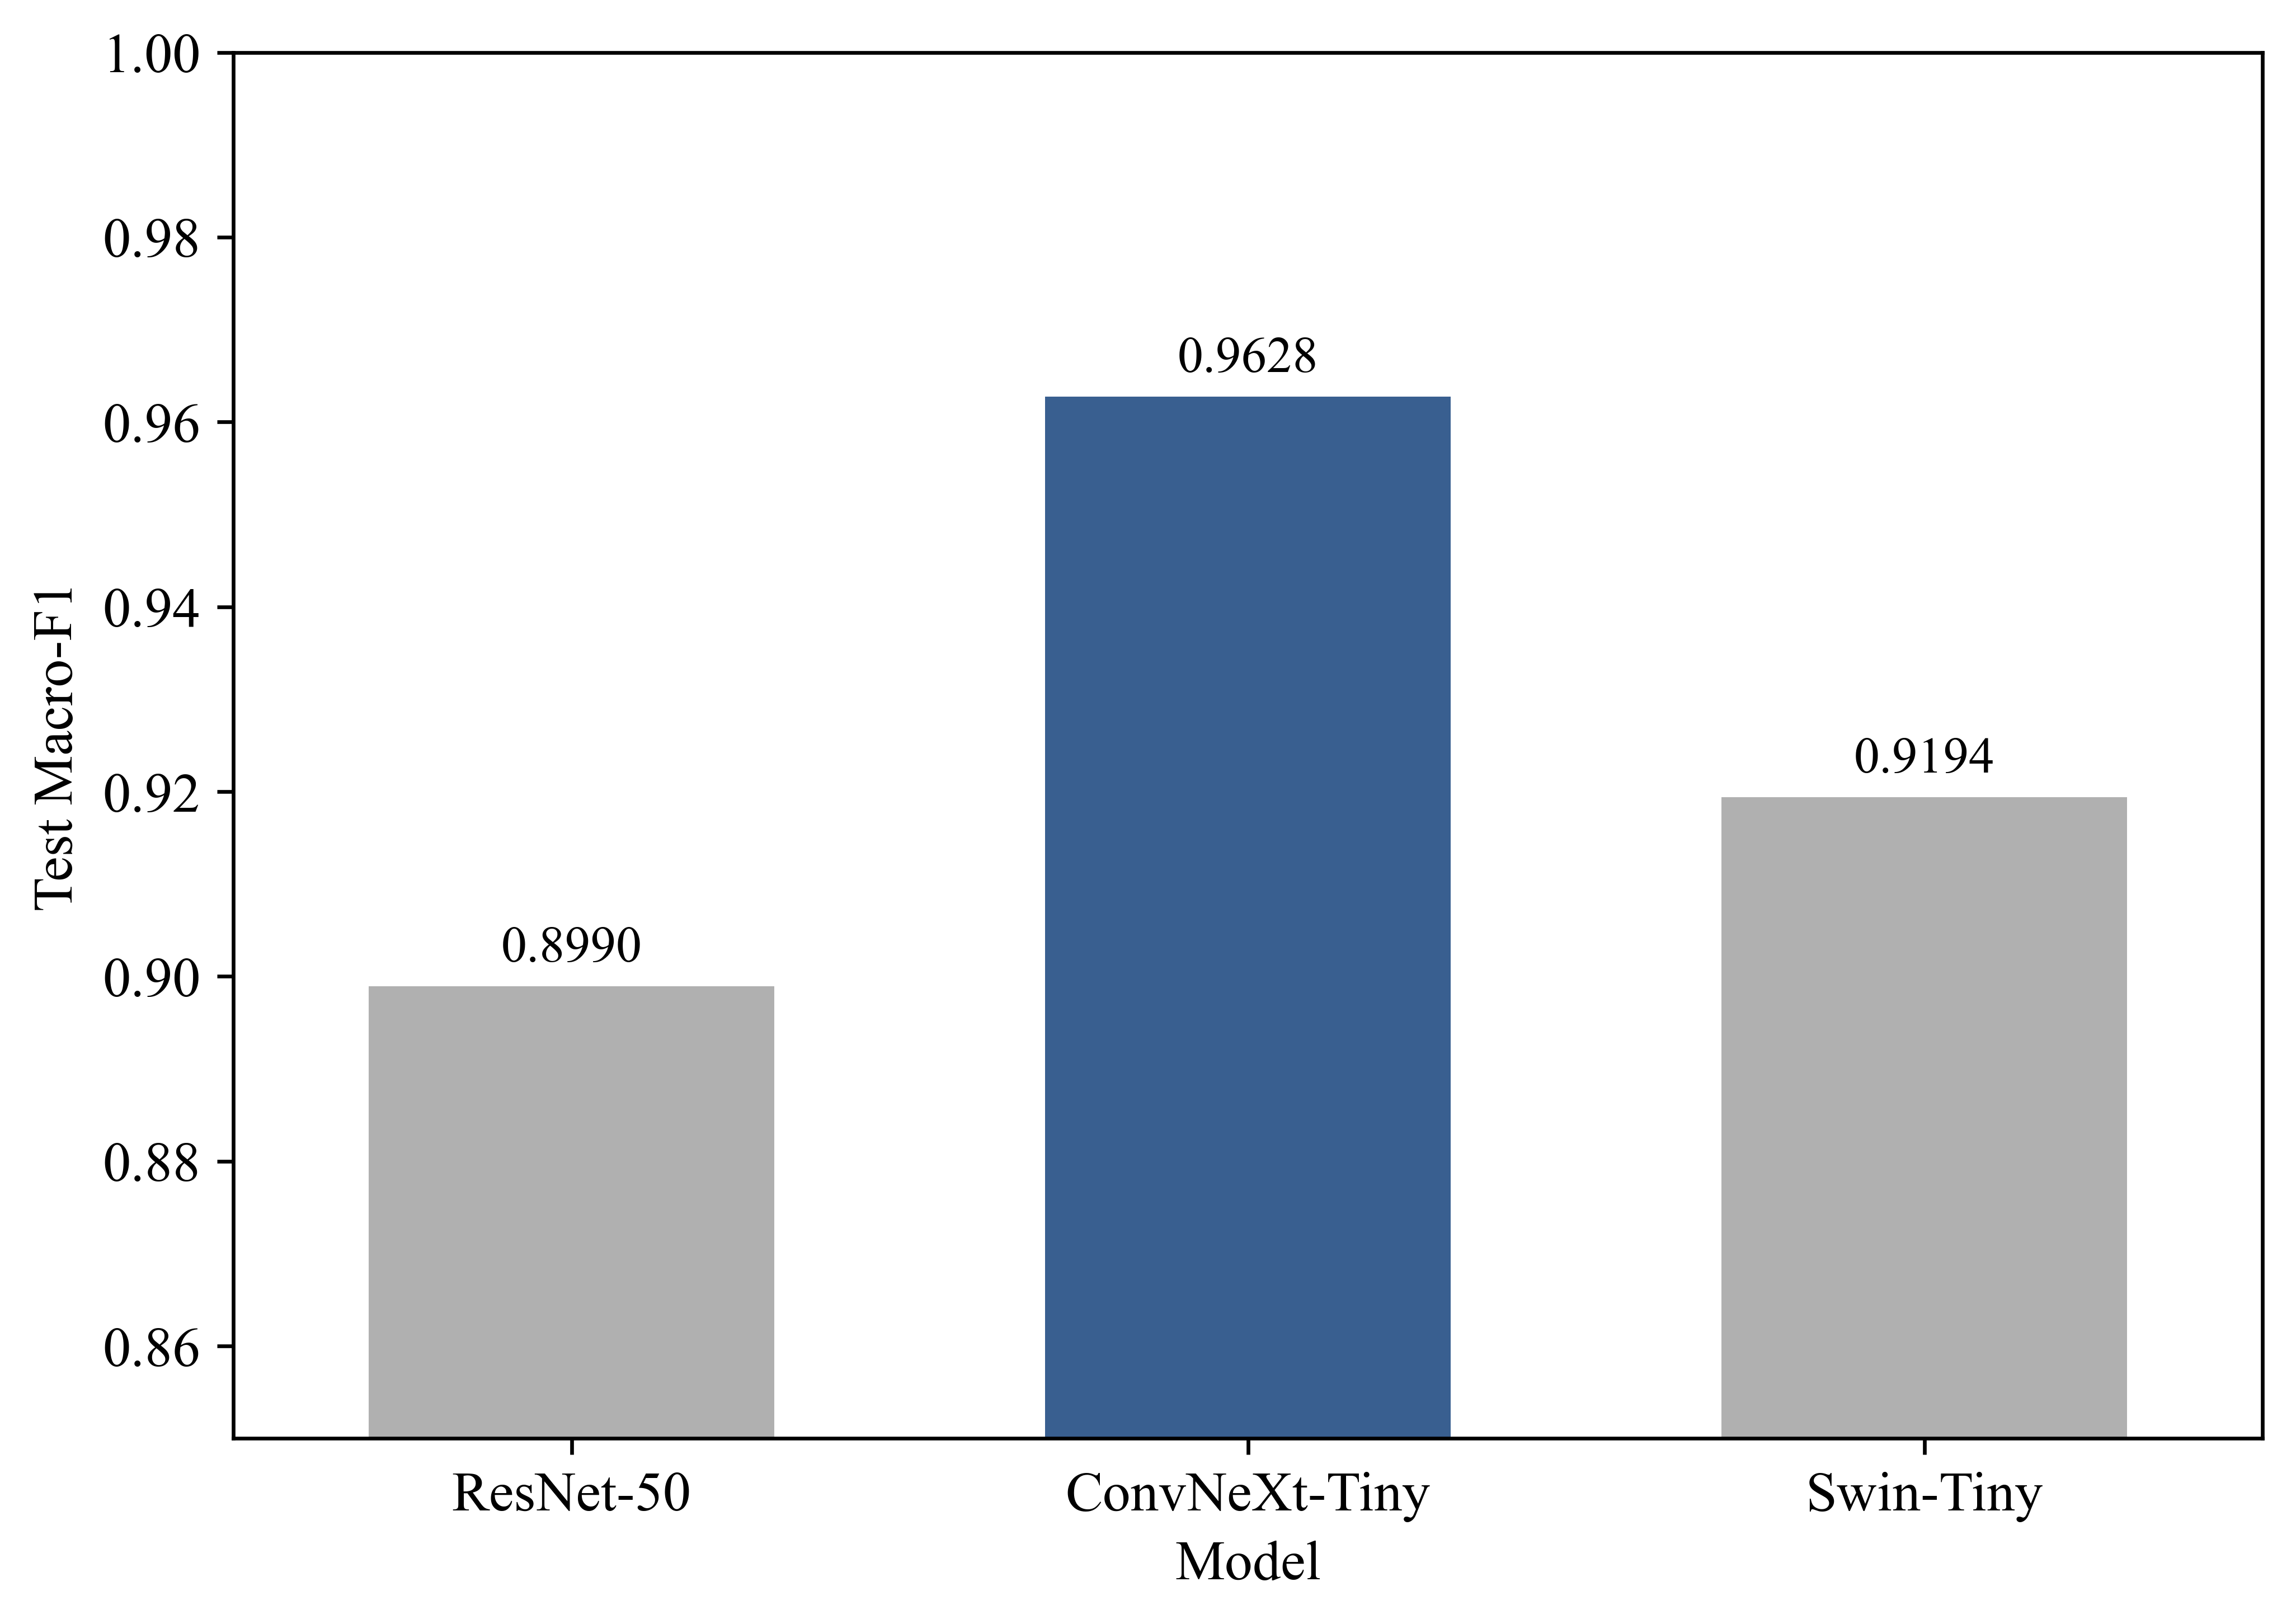

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# Font settings (Journal style)
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["font.size"] = 12

df = pd.DataFrame({
    "Model": ["ResNet-50", "ConvNeXt-Tiny", "Swin-Tiny"],
    "Test Macro-F1": [0.8989543849, 0.9627530771, 0.9194152623]
})

plt.figure(figsize=(7,5), dpi=600)

palette = {
    "ResNet-50": "#B0B0B0",
    "ConvNeXt-Tiny": "#2A5D9F",   # highlighted best model
    "Swin-Tiny": "#B0B0B0"
}

ax = sns.barplot(
    data=df,
    x="Model",
    y="Test Macro-F1",
    width=0.6,
    palette=palette
)

ax.set_ylim(0.85, 1.00)
ax.set_ylabel("Test Macro-F1")
ax.set_xlabel("Model")
ax.set_title("")  # caption will be in the manuscript

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.4f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.tight_layout()
plt.savefig("Figure2_DL_TestMacroF1.png", bbox_inches="tight", dpi=600)
plt.show()



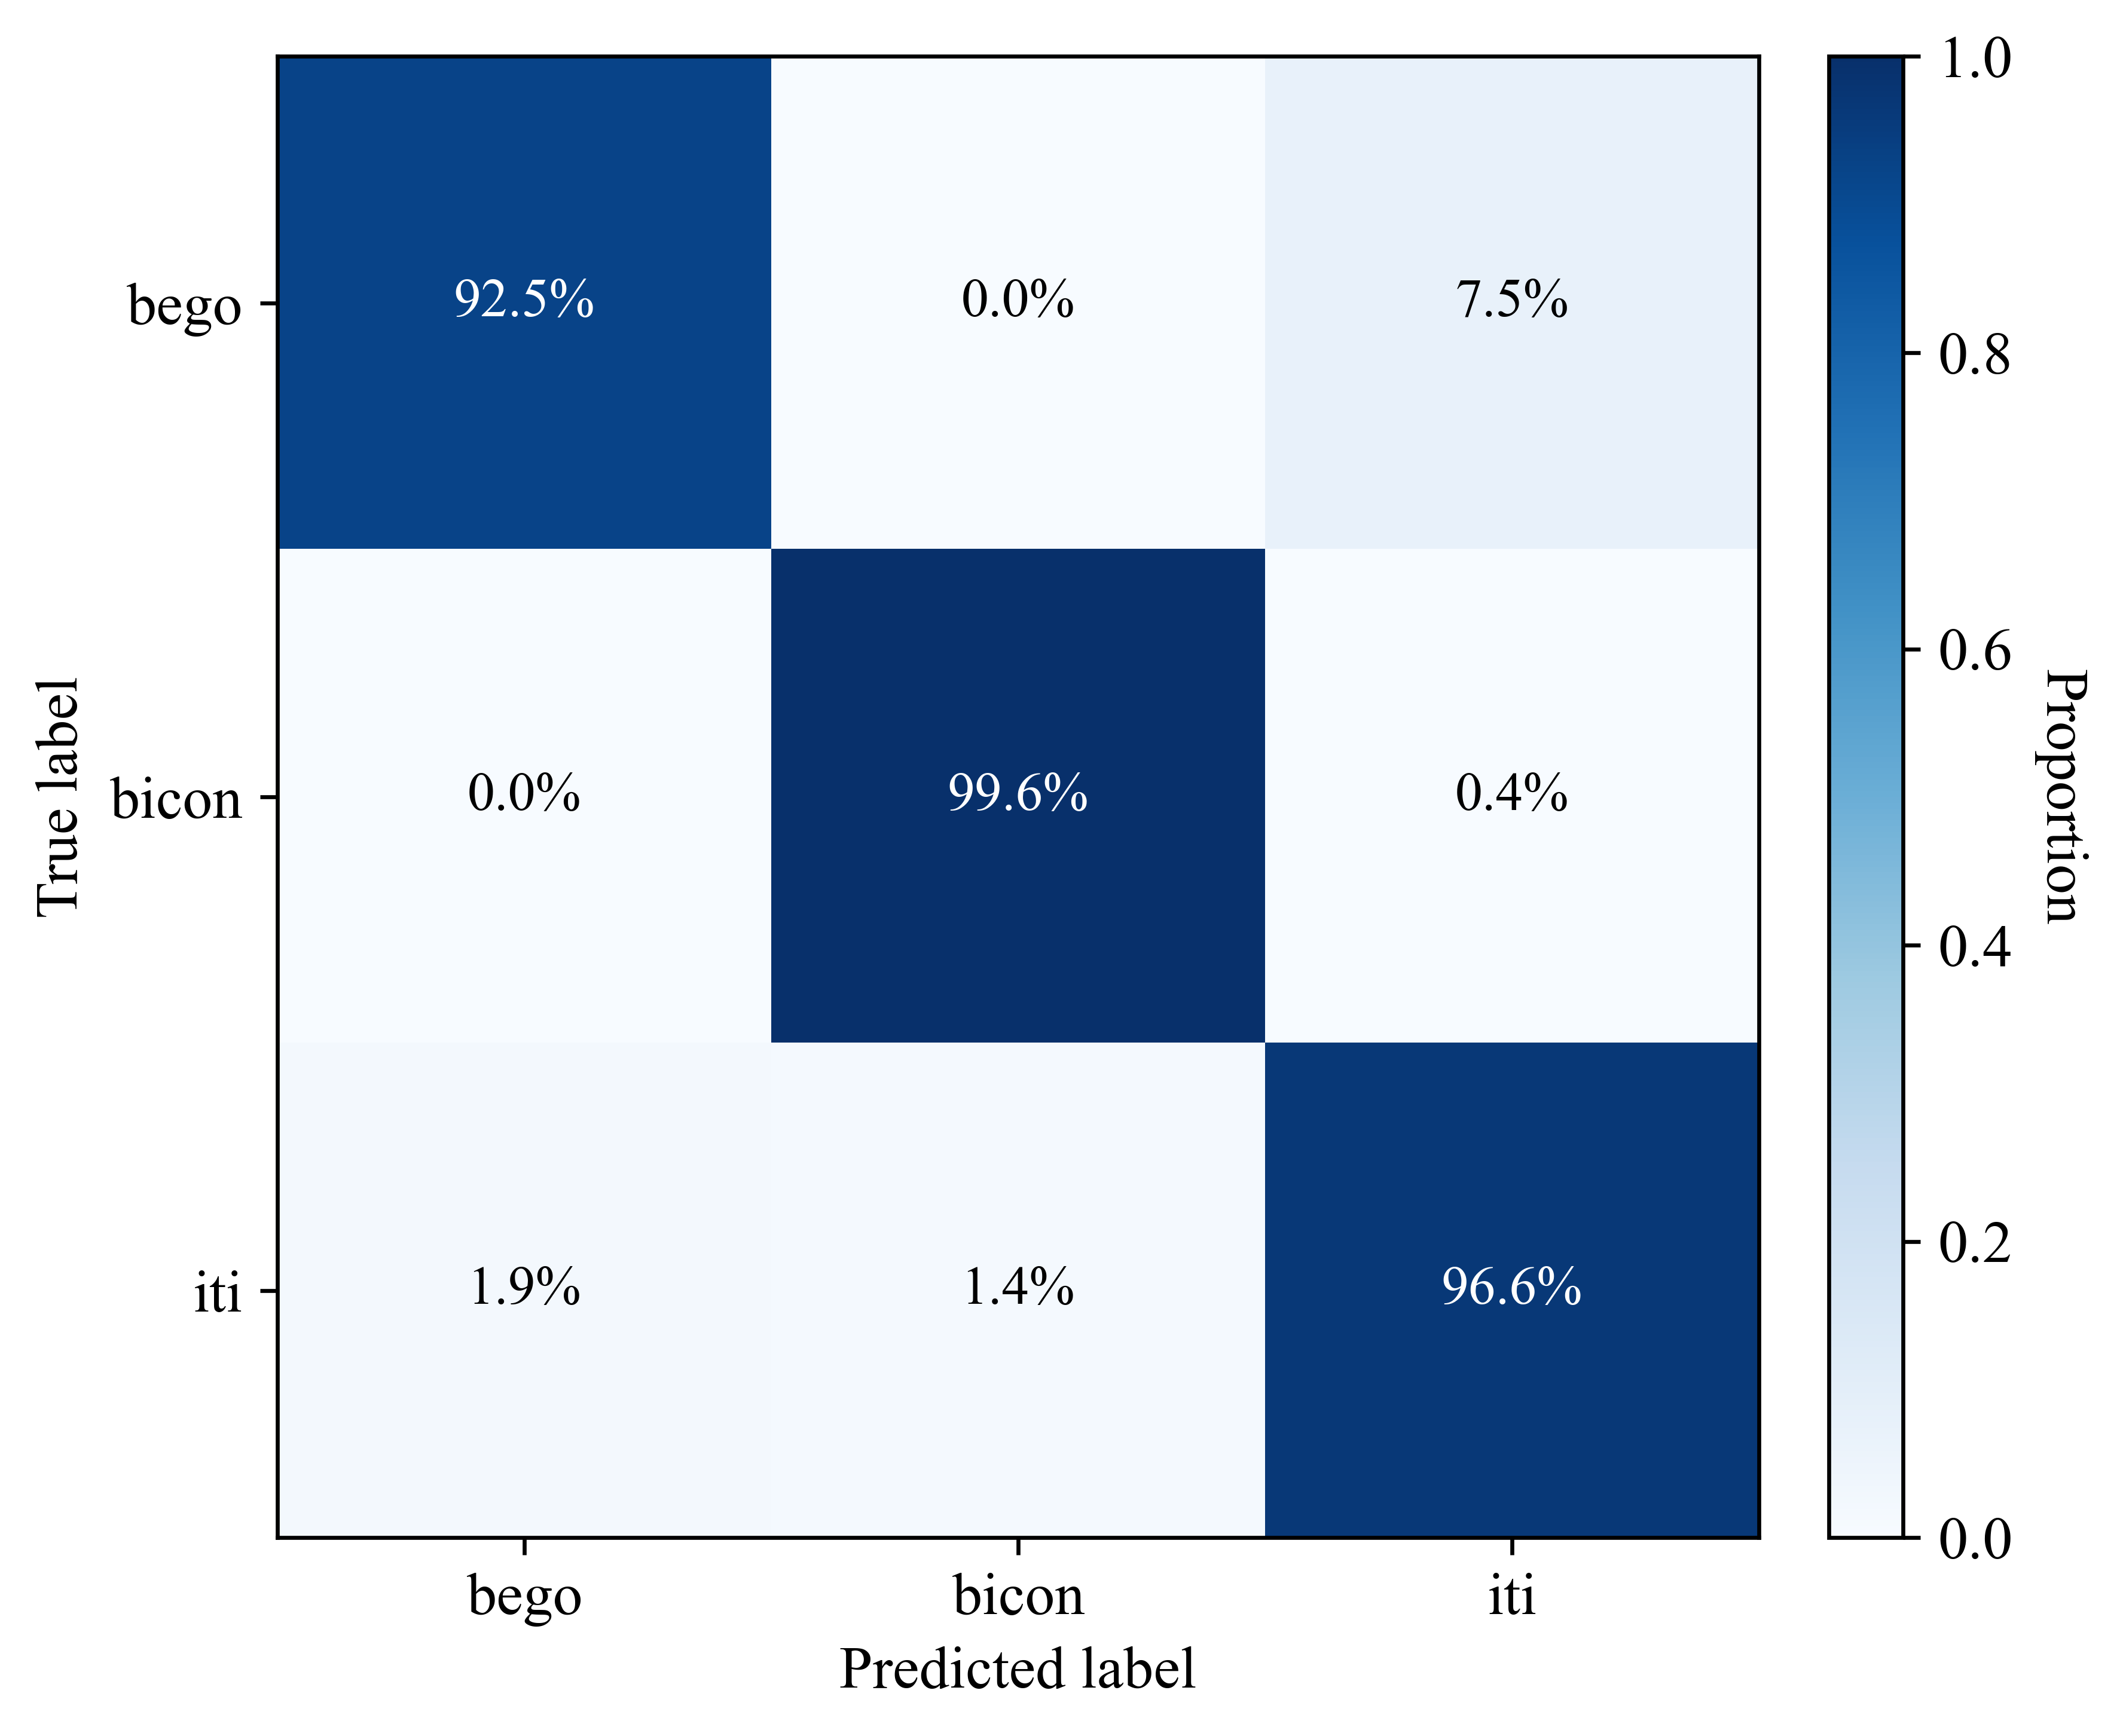

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# --------- Settings (journal style) ----------
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["font.size"] = 12

# --------- Inputs ----------
CM_CSV_PATH = "/Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/runs_grouped_80_20_convnext/results/convnext_tiny_amp_test_confusion_matrix.csv"  # change if needed
CLASS_NAMES = ["bego", "bicon", "iti"]  # ensure order matches your matrix rows/cols

cm = pd.read_csv(CM_CSV_PATH, index_col=0).values.astype(float)

# --------- Row-normalize ----------
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)

# --------- Plot ----------
fig, ax = plt.subplots(figsize=(6, 5), dpi=600)

# SOFT colormap
im = ax.imshow(
    cm_norm,
    cmap="Blues",        # <<< soft academic colormap
    vmin=0.0,
    vmax=1.0,
    aspect="equal"
)

# Axis ticks
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("")

# Colorbar (soft, minimal)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Proportion", rotation=270, labelpad=15)

# Cell annotations (percent)
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        val = cm_norm[i, j]
        ax.text(
            j, i, f"{val*100:.1f}%",
            ha="center", va="center",
            color="black" if val < 0.6 else "white",
            fontsize=11
        )

plt.tight_layout()

# --------- Save ----------
plt.savefig("Figure3_ConfusionMatrix_RowNormalized.png", bbox_inches="tight", dpi=600)


plt.show()


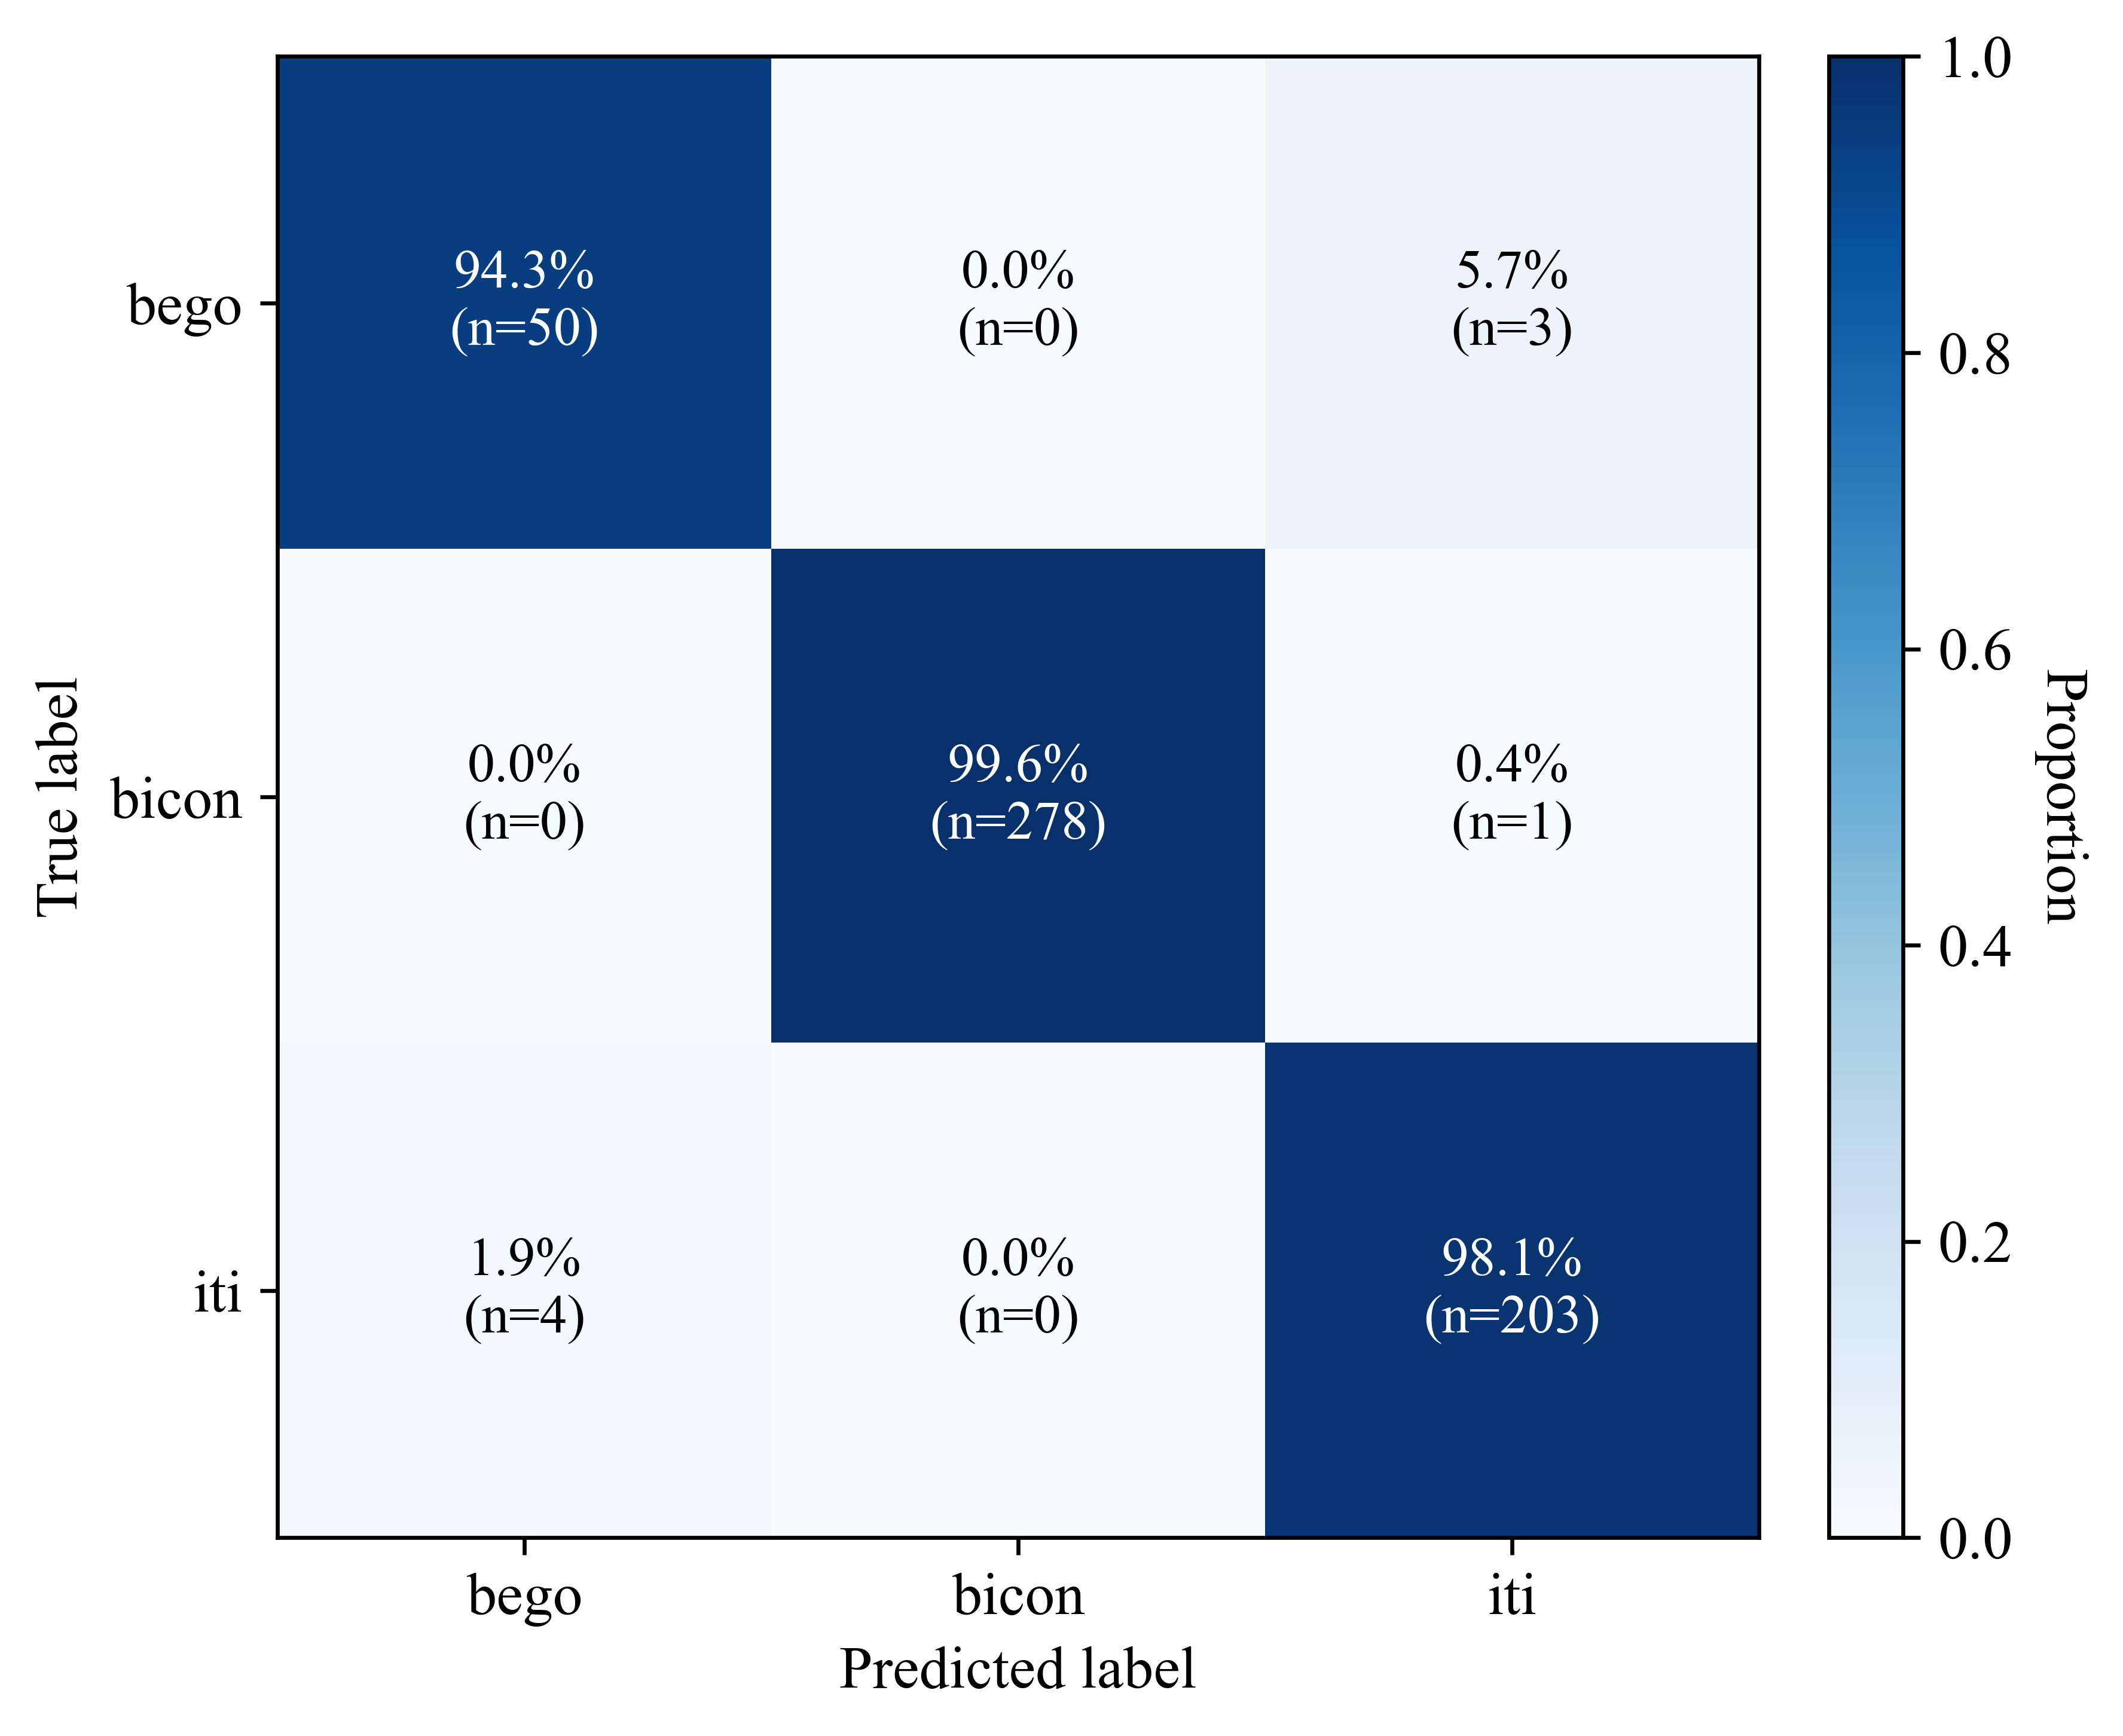

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------------- Font & style (journal-ready) ----------------
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["font.size"] = 12

# ---------------- Confusion Matrix (raw counts) ----------------
cm = np.array([
    [50,  0,  3],
    [ 0, 278, 1],
    [ 4,  0, 203]
], dtype=float)

class_names = ["bego", "bicon", "iti"]

# ---------------- Row normalization ----------------
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = cm / row_sums

# ---------------- Plot ----------------
fig, ax = plt.subplots(figsize=(6, 5), dpi=600)

im = ax.imshow(
    cm_norm,
    cmap="Blues",   # soft academic colors
    vmin=0.0,
    vmax=1.0,
    aspect="equal"
)

# Axis labels
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("")  # caption will be in manuscript

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Proportion", rotation=270, labelpad=15)

# ---------------- Annotate cells ----------------
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        percent = cm_norm[i, j] * 100
        count = int(cm[i, j])
        ax.text(
            j, i,
            f"{percent:.1f}%\n(n={count})",
            ha="center",
            va="center",
            color="white" if percent > 60 else "black",
            fontsize=11
        )

plt.tight_layout()

# ---------------- Save ----------------
plt.savefig("Figure_Fusion_ConfusionMatrix.png", bbox_inches="tight", dpi=600)
plt.show()


Fused train: (2149, 6936)
Fused test : (539, 6936)


/Users/fatmanurortatas/anaconda3/envs/pytorch/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



===== CLASS ORDER CHECK =====
Classifier classes:
[0 1 2]

BRANDS mapping:
{0: 'bego', 1: 'bicon', 2: 'iti'}

Unique y_train:
[0 1 2]

Unique y_test:
[0 1 2]

===== PROBABILITY CHECK =====
y_proba shape:
(539, 3)

First 10 probability rows:
[[9.99139e-01 4.00000e-06 8.57000e-04]
 [9.99987e-01 0.00000e+00 1.30000e-05]
 [9.98184e-01 6.00000e-06 1.81100e-03]
 [9.99899e-01 0.00000e+00 1.01000e-04]
 [5.33099e-01 1.99000e-04 4.66702e-01]
 [9.97781e-01 4.10000e-05 2.17700e-03]
 [7.63132e-01 3.42000e-04 2.36526e-01]
 [9.98032e-01 5.00000e-06 1.96400e-03]
 [3.41575e-01 3.21000e-04 6.58104e-01]
 [9.99989e-01 1.00000e-05 1.00000e-06]]

Row sums of first 10 probability rows:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

===== CONFUSION MATRIX CHECK =====
[[ 51   0   2]
 [  0 277   2]
 [  4   0 203]]

Classification report:
              precision    recall  f1-score   support

        bego       0.93      0.96      0.94        53
       bicon       1.00      0.99      1.00       279
         iti       0.98   

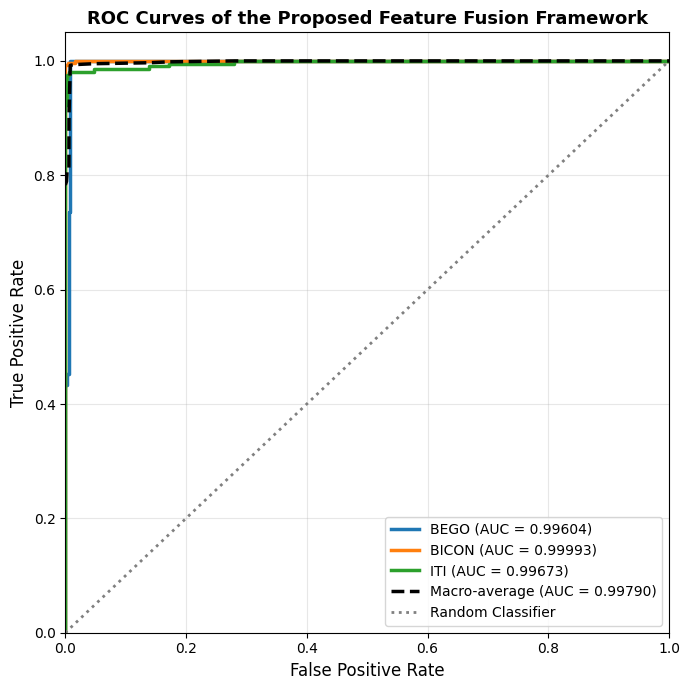

Saved: fusion_results/fusion_lr_roc_curves_revised.png
Saved: fusion_results/fusion_lr_roc_curves_revised.pdf
ROC saved to: fusion_results/fusion_lr_roc_curves_revised.png
       Class      AUC
0       BEGO  0.99604
1      BICON  0.99993
2        ITI  0.99673
3  Macro Avg  0.99790
AUC scores saved.


In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# =========================
# 1) Load SAVED FEATURES
# =========================
mf_dir  = Path("./manual_features")
emb_dir = Path("./embeddings_convnext")
out     = Path("./fusion_results")
out.mkdir(exist_ok=True, parents=True)

# Manual features
X_train_man = np.load(mf_dir/"X_train.npy")
X_test_man  = np.load(mf_dir/"X_test.npy")

train_meta = pd.read_csv(mf_dir/"train_meta.csv")
test_meta  = pd.read_csv(mf_dir/"test_meta.csv")

# ConvNeXt embeddings
E_train = np.load(emb_dir/"E_train.npy")
E_test  = np.load(emb_dir/"E_test.npy")

# Sanity checks
assert X_train_man.shape[0] == E_train.shape[0] == len(train_meta)
assert X_test_man.shape[0]  == E_test.shape[0]  == len(test_meta)

# =========================
# 2) Build FUSED FEATURES
# =========================
X_train_fused = np.concatenate([E_train, X_train_man], axis=1).astype(np.float32)
X_test_fused  = np.concatenate([E_test,  X_test_man ], axis=1).astype(np.float32)

y_train = train_meta["y"].values
y_test  = test_meta["y"].values

BRANDS = ["bego", "bicon", "iti"]

print("Fused train:", X_train_fused.shape)
print("Fused test :", X_test_fused.shape)

# =========================
# 3) Train FINAL LR MODEL
# =========================
pipe_lr = Pipeline([
    ("scaler", StandardScaler(with_mean=True)),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

pipe_lr.fit(X_train_fused, y_train)

# =========================
# 4) Predict PROBABILITIES
# =========================
y_proba = pipe_lr.predict_proba(X_test_fused)
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# =========================
# ROC VALIDATION CHECKS
# =========================
print("\n===== CLASS ORDER CHECK =====")
print("Classifier classes:")
print(pipe_lr.named_steps["clf"].classes_)

print("\nBRANDS mapping:")
print({i: b for i, b in enumerate(BRANDS)})

print("\nUnique y_train:")
print(np.unique(y_train))

print("\nUnique y_test:")
print(np.unique(y_test))


print("\n===== PROBABILITY CHECK =====")
print("y_proba shape:")
print(y_proba.shape)

print("\nFirst 10 probability rows:")
print(np.round(y_proba[:10], 6))

print("\nRow sums of first 10 probability rows:")
print(np.round(y_proba[:10].sum(axis=1), 6))


print("\n===== CONFUSION MATRIX CHECK =====")
y_pred = pipe_lr.predict(X_test_fused)

cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=BRANDS))


print("\n===== ROC AUC VERIFICATION =====")
y_test_bin_check = label_binarize(y_test, classes=np.arange(len(BRANDS)))

for i, brand in enumerate(BRANDS):
    auc_score = roc_auc_score(y_test_bin_check[:, i], y_proba[:, i])
    print(f"{brand.upper()} AUC: {auc_score:.6f}")

macro_auc_ovr = roc_auc_score(
    y_test_bin_check,
    y_proba,
    average="macro",
    multi_class="ovr"
)
print(f"Macro-average AUC OvR: {macro_auc_ovr:.6f}")
assert y_proba.shape == (len(y_test), len(BRANDS))

# =========================
# 5) ROC (OvR)
# =========================
y_test_bin = label_binarize(y_test, classes=np.arange(len(BRANDS)))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(len(BRANDS)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(BRANDS))]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(len(BRANDS)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= len(BRANDS)

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# =========================
# 6) Plot & Save
# =========================
# =========================
# 6) Publication-quality ROC
# =========================

plt.figure(figsize=(7,7))

colors = {
    "bego": "#1f77b4",
    "bicon": "#ff7f0e",
    "iti": "#2ca02c"
}

for i, name in enumerate(BRANDS):
    plt.plot(
        fpr[i],
        tpr[i],
        lw=2.5,
        color=colors[name],
        label=f"{name.upper()} (AUC = {roc_auc[i]:.5f})"
    )

plt.plot(
    fpr["macro"],
    tpr["macro"],
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Macro-average (AUC = {roc_auc['macro']:.5f})"
)

plt.plot(
    [0,1],
    [0,1],
    color="gray",
    linestyle=":",
    linewidth=2,
    label="Random Classifier"
)

plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title(
    "ROC Curves of the Proposed Feature Fusion Framework",
    fontsize=13,
    fontweight="bold"
)

plt.legend(
    loc="lower right",
    fontsize=10,
    frameon=True
)

plt.grid(alpha=0.3)

plt.tight_layout()

roc_png = out/"fusion_lr_roc_curves_revised.png"
roc_pdf = out/"fusion_lr_roc_curves_revised.pdf"

plt.savefig(
    roc_png,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    roc_pdf,
    bbox_inches="tight"
)

plt.show()

print("Saved:", roc_png)
print("Saved:", roc_pdf)

print("ROC saved to:", roc_png)

# =========================
# 7) Save AUC values
# =========================
auc_df = pd.DataFrame({
    "Class": ["BEGO","BICON","ITI","Macro Avg"],
    "AUC":[
        roc_auc[0],
        roc_auc[1],
        roc_auc[2],
        roc_auc["macro"]
    ]
})

auc_df["AUC"] = auc_df["AUC"].round(5)

print(auc_df)

auc_df.to_csv(
    out/"revised_auc_scores.csv",
    index=False
)
print("AUC scores saved.")


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# =========================
# 1) Load SAVED FEATURES
# =========================
mf_dir  = Path("./manual_features")
emb_dir = Path("./embeddings_convnext")
out     = Path("./fusion_results")
out.mkdir(exist_ok=True, parents=True)

# Manual features
X_train_man = np.load(mf_dir/"X_train.npy")
X_test_man  = np.load(mf_dir/"X_test.npy")

train_meta = pd.read_csv(mf_dir/"train_meta.csv")
test_meta  = pd.read_csv(mf_dir/"test_meta.csv")

# ConvNeXt embeddings
E_train = np.load(emb_dir/"E_train.npy")
E_test  = np.load(emb_dir/"E_test.npy")

# Sanity checks
assert X_train_man.shape[0] == E_train.shape[0] == len(train_meta)
assert X_test_man.shape[0]  == E_test.shape[0]  == len(test_meta)

# =========================
# 2) Build FUSED FEATURES
# =========================
X_train_fused = np.concatenate([E_train, X_train_man], axis=1).astype(np.float32)
X_test_fused  = np.concatenate([E_test,  X_test_man ], axis=1).astype(np.float32)

y_train = train_meta["y"].values
y_test  = test_meta["y"].values

BRANDS = ["bego", "bicon", "iti"]

print("Fused train:", X_train_fused.shape)
print("Fused test :", X_test_fused.shape)

# =========================
# 3) Train FINAL LR MODEL
# =========================
pipe_lr = Pipeline([
    ("scaler", StandardScaler(with_mean=True)),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

pipe_lr.fit(X_train_fused, y_train)

# =========================
# 4) Predict PROBABILITIES
# =========================
y_proba = pipe_lr.predict_proba(X_test_fused)
assert y_proba.shape == (len(y_test), len(BRANDS))

# =========================
# 5) ROC (OvR)
# =========================
y_test_bin = label_binarize(y_test, classes=np.arange(len(BRANDS)))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(len(BRANDS)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(BRANDS))]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(len(BRANDS)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= len(BRANDS)

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# =========================
# 6) Plot & Save
# =========================
plt.figure(figsize=(6,6))

bego_idx = BRANDS.index("bego")
plt.plot(fpr[bego_idx], tpr[bego_idx],
         label=f"BEGO (AUC = {roc_auc[bego_idx]:.3f})",
         linewidth=3)

for i, name in enumerate(BRANDS):
    if i == bego_idx: continue
    plt.plot(fpr[i], tpr[i],
             label=f"{name.upper()} (AUC = {roc_auc[i]:.3f})",
             linewidth=1.5)

plt.plot(fpr["macro"], tpr["macro"],
         label=f"Macro-average (AUC = {roc_auc['macro']:.3f})",
         linestyle="--", linewidth=2)

plt.plot([0,1], [0,1], "k--", alpha=0.4)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Proposed Feature Fusion Model (OvR)")
plt.legend(loc="lower right")
plt.tight_layout()

roc_png = out/"fusion_lr_roc_curves.png"
plt.savefig(roc_png, dpi=300, bbox_inches="tight")
plt.show()

print("ROC saved to:", roc_png)

# =========================
# 7) Save AUC values
# =========================
auc_df = pd.DataFrame(
    [{"class": BRANDS[i], "auc": roc_auc[i]} for i in range(len(BRANDS))] +
    [{"class": "macro_avg", "auc": roc_auc["macro"]}]
)
auc_df.to_csv(out/"fusion_lr_auc_scores.csv", index=False)
print("AUC scores saved.")
print("Classifier classes:")
print(pipe_lr.named_steps["clf"].classes_)

print("Unique y_train:")
print(np.unique(y_train))

print("Unique y_test:")
print(np.unique(y_test))

In [32]:
# -*- coding: utf-8 -*-
"""
Tek script: ConvNeXt-Tiny (.pt) ile test klasöründeki ROI görsellerine
(1) True/Pred/Conf yazıp kaydeder (metin bandı otomatik sığar, kırpılmaz)
(2) Her sınıf için 2x2 (4'lü) yüksek çözünürlüklü kolajlar üretir

Girdi klasör yapısı örnek:
TEST_ROOT/
  bego/*.jpg
  bicon/*.jpg
  iti/*.jpg
  unknown/*.jpg  (opsiyonel)

Çıktı:
OUT_PRED_DIR/<class>/*.jpg   (annotated)
OUT_QUAD_DIR/<class>_quad_###.png  (2x2 kolaj)
"""

import re
from pathlib import Path

import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from torchvision.models import convnext_tiny


# =========================
# KULLANICI AYARLARI
# =========================
MODEL_PATH = r"/Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/runs_grouped_80_20_convnext/models/convnext_tiny_amp_fold5_best.pt"
TEST_ROOT = Path(r"/Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/roi_brands/test")

# 1) Tahmin + metin yazılmış çıktılar
OUT_PRED_DIR = Path(r"/Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/pred_vis1")

# 2) 4'lü kolaj çıktıları
OUT_QUAD_DIR = Path(r"/Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/fig_quads_hiRes")

CLASS_NAMES = ["bego", "bicon", "iti"]     # eğitimdeki label sırası
IMG_SIZE = 224                              # model input
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Görsel uzantıları
EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# Metin bandı ayarları (annotated çıktılar için)
BAND_H = 80
BAND_PAD = 12
FONT_MAX = 28
FONT_MIN = 10

# ROI çok küçükse yazı için önce büyüt (annotated çıktılarda okunurluk)
MIN_WIDTH_BEFORE_TEXT = 700

# Kolaj ayarları (yayın için yüksek çözünürlük)
CELL_W, CELL_H = 1200, 1200     # her panel
COLLAGE_PAD = 40                # paneller arası boşluk
COLLAGE_TITLE_H = 90            # kolaj başlığı alanı
COLLAGE_TITLE_FONT = 52
PANEL_TAG_FONT = 42             # (a)(b)(c)(d) bandı fontu
PANEL_TAG_H = 80                # panel üst bandı
BG = (255, 255, 255)

# İstersen dosya adını panel bandında göstermeyi kapat
SHOW_FILENAME_ON_PANEL = False


# =========================
# FONT YÜKLEME (macOS)
# =========================
FONT_CANDIDATES = [
    "/System/Library/Fonts/Supplemental/Arial.ttf",
    "/System/Library/Fonts/Supplemental/Helvetica.ttf",
    "/System/Library/Fonts/Helvetica.ttc",
    "/Library/Fonts/Arial.ttf",
]

def load_font(size: int):
    for fp in FONT_CANDIDATES:
        try:
            return ImageFont.truetype(fp, size)
        except Exception:
            pass
    return ImageFont.load_default()


# =========================
# METİN ÖLÇME / SIĞDIRMA
# =========================
def text_size(draw: ImageDraw.ImageDraw, text: str, font: ImageFont.ImageFont):
    bbox = draw.textbbox((0, 0), text, font=font)
    return bbox[2] - bbox[0], bbox[3] - bbox[1]

def draw_text_fit(img_pil: Image.Image, text: str,
                  band_h=BAND_H, pad=BAND_PAD,
                  max_font=FONT_MAX, min_font=FONT_MIN):
    """
    Metni üst banda sığdırır: fontu küçültür; sığmazsa 2 satıra böler.
    True/Pred kesilmesin diye tasarlandı.
    """
    img = img_pil.convert("RGB").copy()
    draw = ImageDraw.Draw(img)
    w, h = img.size

    # Band
    draw.rectangle([0, 0, w, band_h], fill=(0, 0, 0))

    # 1) Tek satır: fontu küçülterek sığdır
    font_size = max_font
    while font_size >= min_font:
        font = load_font(font_size)
        tw, th = text_size(draw, text, font)
        if tw <= (w - 2 * pad):
            y = (band_h - th) // 2
            draw.text((pad, y), text, fill=(255, 255, 255), font=font)
            return img
        font_size -= 1

    # 2) Hala sığmadı: iki satıra böl
    if " | " in text:
        parts = text.split(" | ")
        line1 = parts[0]                # True: ...
        line2 = " | ".join(parts[1:])   # Pred: ...
    else:
        # en kötü durumda ortadan böl
        mid = len(text) // 2
        line1, line2 = text[:mid], text[mid:]

    # İki satır için okunur başlangıç fontu
    fs = max(min_font, 22)
    while fs >= min_font:
        font = load_font(fs)
        tw1, th1 = text_size(draw, line1, font)
        tw2, th2 = text_size(draw, line2, font)
        if tw1 <= (w - 2*pad) and tw2 <= (w - 2*pad):
            break
        fs -= 1
    font = load_font(max(fs, min_font))

    tw1, th1 = text_size(draw, line1, font)
    tw2, th2 = text_size(draw, line2, font)

    total_h = th1 + th2 + 6
    y1 = (band_h - total_h) // 2
    y2 = y1 + th1 + 6

    draw.text((pad, y1), line1, fill=(255, 255, 255), font=font)
    draw.text((pad, y2), line2, fill=(255, 255, 255), font=font)
    return img


# =========================
# PREPROCESS (ImageNet norm)
# =========================
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_pil(img_pil: Image.Image):
    img = img_pil.convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = (arr - IMAGENET_MEAN) / IMAGENET_STD
    x = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0)  # (1,3,H,W)
    return x


# =========================
# KOLAJ YARDIMCILARI
# =========================
def letterbox(img: Image.Image, target_w: int, target_h: int, bg=BG):
    img = img.convert("RGB")
    w, h = img.size
    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    img_resized = img.resize((new_w, new_h), resample=Image.Resampling.LANCZOS)
    canvas = Image.new("RGB", (target_w, target_h), bg)
    x = (target_w - new_w) // 2
    y = (target_h - new_h) // 2
    canvas.paste(img_resized, (x, y))
    return canvas

def draw_panel_tag(panel: Image.Image, tag_text: str, extra_text: str = ""):
    """Panel üst bandı: (a)(b)(c)(d) + opsiyonel kısa bilgi."""
    img = panel.copy()
    draw = ImageDraw.Draw(img)
    draw.rectangle([0, 0, img.width, PANEL_TAG_H], fill=(0, 0, 0))

    font = load_font(PANEL_TAG_FONT)
    text = tag_text if not extra_text else f"{tag_text}  {extra_text}"

    # çok uzunsa kısalt
    if len(text) > 70:
        text = text[:67] + "..."

    draw.text((20, 18), text, fill=(255, 255, 255), font=font)
    return img

def make_quad(img_paths, out_path, title: str):
    """2x2 kolaj üretir (yüksek çözünürlük)."""
    canvas_w = 2 * CELL_W + 3 * COLLAGE_PAD
    canvas_h = COLLAGE_TITLE_H + 2 * CELL_H + 3 * COLLAGE_PAD

    canvas = Image.new("RGB", (canvas_w, canvas_h), BG)
    draw = ImageDraw.Draw(canvas)

    # başlık
    title_font = load_font(COLLAGE_TITLE_FONT)
    draw.text((COLLAGE_PAD, 18), title, fill=(0, 0, 0), font=title_font)

    tags = ["(a)", "(b)", "(c)", "(d)"]

    for i, p in enumerate(img_paths):
        img = Image.open(p).convert("RGB")
        panel = letterbox(img, CELL_W, CELL_H, bg=BG)

        extra = p.name if SHOW_FILENAME_ON_PANEL else ""
        panel = draw_panel_tag(panel, tags[i], extra_text=extra)

        r = i // 2
        c = i % 2
        x = COLLAGE_PAD + c * (CELL_W + COLLAGE_PAD)
        y = COLLAGE_TITLE_H + COLLAGE_PAD + r * (CELL_H + COLLAGE_PAD)
        canvas.paste(panel, (x, y))

    canvas.save(out_path)


# =========================
# ANA AKIŞ
# =========================
def main():
    OUT_PRED_DIR.mkdir(parents=True, exist_ok=True)
    OUT_QUAD_DIR.mkdir(parents=True, exist_ok=True)

    # ---- MODEL ----
    model = convnext_tiny(weights=None)
    in_features = model.classifier[2].in_features
    model.classifier[2] = torch.nn.Linear(in_features, len(CLASS_NAMES))

    state_dict = torch.load(MODEL_PATH, map_location="cpu")
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print("Missing keys:", len(missing))
    print("Unexpected keys:", len(unexpected))

    model.to(DEVICE).eval()

    # ---- TEST klasörlerini bul ----
    if not TEST_ROOT.exists():
        raise FileNotFoundError(f"TEST_ROOT bulunamadı: {TEST_ROOT}")

    class_dirs = [p for p in TEST_ROOT.iterdir() if p.is_dir()]
    print("\nTEST_ROOT:", TEST_ROOT)
    print("Sınıf klasörleri:", [p.name for p in class_dirs])

    # ---- 1) Annotated çıktıları üret ----
    saved = 0
    opened = 0

    for d in class_dirs:
        true_label = d.name
        out_sub = OUT_PRED_DIR / true_label
        out_sub.mkdir(parents=True, exist_ok=True)

        imgs = [p for p in d.rglob("*") if p.is_file() and p.suffix.lower() in EXTS]
        print(f"  - {true_label}: {len(imgs)} görsel")

        for img_path in imgs:
            try:
                img = Image.open(img_path).convert("RGB")
                opened += 1
            except Exception:
                continue

            # küçük ROI'lerde yazı okunur olsun diye büyüt
            if img.width < MIN_WIDTH_BEFORE_TEXT:
                scale = MIN_WIDTH_BEFORE_TEXT / img.width
                new_w = int(img.width * scale)
                new_h = int(img.height * scale)
                img = img.resize((new_w, new_h), resample=Image.Resampling.LANCZOS)

            x = preprocess_pil(img).to(DEVICE)
            with torch.no_grad():
                logits = model(x)
                probs = F.softmax(logits, dim=1)[0]
                pred_id = int(torch.argmax(probs).item())
                conf = float(probs[pred_id].item())
                pred_name = CLASS_NAMES[pred_id]

            if true_label in CLASS_NAMES:
                text = f"True: {true_label} | Pred: {pred_name} ({conf:.3f})"
            else:
                text = f"Pred: {pred_name} ({conf:.3f})"

            vis = draw_text_fit(img, text, band_h=BAND_H, pad=BAND_PAD,
                                max_font=FONT_MAX, min_font=FONT_MIN)

            out_path = out_sub / img_path.name
            vis.save(out_path)
            saved += 1

    print(f"\nAçılabilen görsel: {opened}")
    print(f"Kaydedilen annotated çıktı: {saved}")
    print("Annotated klasör:", OUT_PRED_DIR.resolve())

    # ---- 2) Kolaj üret (annotated çıktılardan) ----
    quad_count = 0
    for class_dir in sorted([p for p in OUT_PRED_DIR.iterdir() if p.is_dir()]):
        imgs = sorted([p for p in class_dir.rglob("*") if p.is_file() and p.suffix.lower() in EXTS])
        if len(imgs) < 4:
            continue

        for i in range(0, len(imgs), 4):
            group = imgs[i:i+4]
            if len(group) < 4:
                break
            quad_count += 1
            out_path = OUT_QUAD_DIR / f"{class_dir.name}_quad_{quad_count:03d}.png"
            make_quad(group, out_path, title=f"Test set: {class_dir.name}")

    print(f"\nToplam kolaj: {quad_count}")
    print("Kolaj klasörü:", OUT_QUAD_DIR.resolve())


if __name__ == "__main__":
    main()


Missing keys: 0
Unexpected keys: 0

TEST_ROOT: /Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/roi_brands/test
Sınıf klasörleri: ['iti', 'bicon', 'unknown', 'bego']
  - iti: 51 görsel
  - bicon: 80 görsel
  - unknown: 0 görsel
  - bego: 4 görsel

Açılabilen görsel: 135
Kaydedilen annotated çıktı: 135
Annotated klasör: /Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/pred_vis1

Toplam kolaj: 33
Kolaj klasörü: /Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/fig_quads_hiRes


In [ ]:
# -*- coding: utf-8 -*-
"""
Tek script:
1) ConvNeXt-Tiny ile test görsellerini annotate eder (True/Pred/Conf metni kırpılmaz)
2) 2x2 yüksek çözünürlüklü KARIŞIK kolajlar üretir (bego+bicon+iti karışık)
"""

from pathlib import Path
import random

import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from torchvision.models import convnext_tiny


# =========================
# KULLANICI AYARLARI
# =========================
MODEL_PATH = r"/Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/runs_grouped_80_20_convnext/models/convnext_tiny_amp_fold5_best.pt"
TEST_ROOT = Path(r"/Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/dataset/toplu")

OUT_PRED_DIR = Path(r"/Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/pred_vis1")
OUT_QUAD_DIR = Path(r"/Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/fig_quads_mixed_hiRes")

CLASS_NAMES = ["bego", "bicon", "iti"]     # eğitimdeki label sırası
IMG_SIZE = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# Annotate yazı ayarları
BAND_H = 80
BAND_PAD = 12
FONT_MAX = 28
FONT_MIN = 10
MIN_WIDTH_BEFORE_TEXT = 700

# Kolaj ayarları
CELL_W, CELL_H = 1200, 1200
COLLAGE_PAD = 40
COLLAGE_TITLE_H = 90
COLLAGE_TITLE_FONT = 52
PANEL_TAG_FONT = 42
PANEL_TAG_H = 80
BG = (255, 255, 255)

# Karışık kolaj kaç tane üretilecek?
N_MIXED_QUADS = 30

# Her kolajda sınıf başına en az 1 görsel olsun mu?
BALANCED_EACH_QUAD = True

# Rastgelelik sabiti (aynı kolajları tekrar üretmek için)
RANDOM_SEED = 42


# =========================
# FONT YÜKLEME (macOS)
# =========================
FONT_CANDIDATES = [
    "/System/Library/Fonts/Supplemental/Arial.ttf",
    "/System/Library/Fonts/Supplemental/Helvetica.ttf",
    "/System/Library/Fonts/Helvetica.ttc",
    "/Library/Fonts/Arial.ttf",
]

def load_font(size: int):
    for fp in FONT_CANDIDATES:
        try:
            return ImageFont.truetype(fp, size)
        except Exception:
            pass
    return ImageFont.load_default()


# =========================
# METİN SIĞDIRMA
# =========================
def text_size(draw: ImageDraw.ImageDraw, text: str, font: ImageFont.ImageFont):
    bbox = draw.textbbox((0, 0), text, font=font)
    return bbox[2] - bbox[0], bbox[3] - bbox[1]

def draw_text_fit(img_pil: Image.Image, text: str,
                  band_h=BAND_H, pad=BAND_PAD,
                  max_font=FONT_MAX, min_font=FONT_MIN):
    img = img_pil.convert("RGB").copy()
    draw = ImageDraw.Draw(img)
    w, _ = img.size

    draw.rectangle([0, 0, w, band_h], fill=(0, 0, 0))

    # Tek satır dene
    fs = max_font
    while fs >= min_font:
        font = load_font(fs)
        tw, th = text_size(draw, text, font)
        if tw <= (w - 2 * pad):
            y = (band_h - th) // 2
            draw.text((pad, y), text, fill=(255, 255, 255), font=font)
            return img
        fs -= 1

    # 2 satır (True / Pred) - garanti
    if " | " in text:
        parts = text.split(" | ")
        line1 = parts[0]
        line2 = " | ".join(parts[1:])
    else:
        mid = len(text) // 2
        line1, line2 = text[:mid], text[mid:]

    fs = max(min_font, 22)
    while fs >= min_font:
        font = load_font(fs)
        tw1, th1 = text_size(draw, line1, font)
        tw2, th2 = text_size(draw, line2, font)
        if tw1 <= (w - 2*pad) and tw2 <= (w - 2*pad):
            break
        fs -= 1
    font = load_font(max(fs, min_font))

    tw1, th1 = text_size(draw, line1, font)
    tw2, th2 = text_size(draw, line2, font)
    total_h = th1 + th2 + 6
    y1 = (band_h - total_h) // 2
    y2 = y1 + th1 + 6

    draw.text((pad, y1), line1, fill=(255, 255, 255), font=font)
    draw.text((pad, y2), line2, fill=(255, 255, 255), font=font)
    return img


# =========================
# PREPROCESS
# =========================
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_pil(img_pil: Image.Image):
    img = img_pil.convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = (arr - IMAGENET_MEAN) / IMAGENET_STD
    x = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0)
    return x


# =========================
# KOLAJ
# =========================
def letterbox(img: Image.Image, target_w: int, target_h: int, bg=BG):
    img = img.convert("RGB")
    w, h = img.size
    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    img_resized = img.resize((new_w, new_h), resample=Image.Resampling.LANCZOS)
    canvas = Image.new("RGB", (target_w, target_h), bg)
    x = (target_w - new_w) // 2
    y = (target_h - new_h) // 2
    canvas.paste(img_resized, (x, y))
    return canvas

def draw_panel_tag(panel: Image.Image, tag_text: str, small_text: str):
    img = panel.copy()
    draw = ImageDraw.Draw(img)
    draw.rectangle([0, 0, img.width, PANEL_TAG_H], fill=(0, 0, 0))
    font = load_font(PANEL_TAG_FONT)

    # small_text: sınıf adı gibi kısa tut
    text = f"{tag_text}  {small_text}"
    draw.text((20, 18), text, fill=(255, 255, 255), font=font)
    return img

def make_quad(img_paths, out_path, title: str, class_tags):
    canvas_w = 2 * CELL_W + 3 * COLLAGE_PAD
    canvas_h = COLLAGE_TITLE_H + 2 * CELL_H + 3 * COLLAGE_PAD
    canvas = Image.new("RGB", (canvas_w, canvas_h), BG)
    draw = ImageDraw.Draw(canvas)

    title_font = load_font(COLLAGE_TITLE_FONT)
    draw.text((COLLAGE_PAD, 18), title, fill=(0, 0, 0), font=title_font)

    tags = ["(a)", "(b)", "(c)", "(d)"]

    for i, p in enumerate(img_paths):
        img = Image.open(p).convert("RGB")
        panel = letterbox(img, CELL_W, CELL_H, bg=BG)
        panel = draw_panel_tag(panel, tags[i], class_tags[i])

        r = i // 2
        c = i % 2
        x = COLLAGE_PAD + c * (CELL_W + COLLAGE_PAD)
        y = COLLAGE_TITLE_H + COLLAGE_PAD + r * (CELL_H + COLLAGE_PAD)
        canvas.paste(panel, (x, y))

    canvas.save(out_path)


# =========================
# ANA
# =========================
def main():
    random.seed(RANDOM_SEED)

    OUT_PRED_DIR.mkdir(parents=True, exist_ok=True)
    OUT_QUAD_DIR.mkdir(parents=True, exist_ok=True)

    # ---- model ----
    model = convnext_tiny(weights=None)
    in_features = model.classifier[2].in_features
    model.classifier[2] = torch.nn.Linear(in_features, len(CLASS_NAMES))
    state_dict = torch.load(MODEL_PATH, map_location="cpu")
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print("Missing keys:", len(missing))
    print("Unexpected keys:", len(unexpected))

    model.to(DEVICE).eval()

    # ---- 1) Annotate üret ----
    class_dirs = [p for p in TEST_ROOT.iterdir() if p.is_dir()]
    opened, saved = 0, 0

    for d in class_dirs:
        true_label = d.name
        out_sub = OUT_PRED_DIR / true_label
        out_sub.mkdir(parents=True, exist_ok=True)

        imgs = [p for p in d.rglob("*") if p.is_file() and p.suffix.lower() in EXTS]
        print(f"  - {true_label}: {len(imgs)} görsel")

        for img_path in imgs:
            try:
                img = Image.open(img_path).convert("RGB")
                opened += 1
            except Exception:
                continue

            if img.width < MIN_WIDTH_BEFORE_TEXT:
                scale = MIN_WIDTH_BEFORE_TEXT / img.width
                img = img.resize((int(img.width*scale), int(img.height*scale)),
                                 resample=Image.Resampling.LANCZOS)

            x = preprocess_pil(img).to(DEVICE)
            with torch.no_grad():
                probs = F.softmax(model(x), dim=1)[0]
                pred_id = int(torch.argmax(probs).item())
                conf = float(probs[pred_id].item())
                pred_name = CLASS_NAMES[pred_id]

            if true_label in CLASS_NAMES:
                text = f"True: {true_label} | Pred: {pred_name} ({conf:.3f})"
            else:
                text = f"Pred: {pred_name} ({conf:.3f})"

            vis = draw_text_fit(img, text)
            out_path = out_sub / img_path.name
            vis.save(out_path)
            saved += 1

    print(f"\nAçılabilen görsel: {opened}")
    print(f"Kaydedilen annotated çıktı: {saved}")
    print("Annotated klasör:", OUT_PRED_DIR.resolve())

    # ---- 2) Karışık kolaj üret ----
    # Sadece bilinen sınıflar (bego/bicon/iti) ile karışık üretelim
    pools = {}
    for cls in CLASS_NAMES:
        cls_dir = OUT_PRED_DIR / cls
        if cls_dir.exists():
            pools[cls] = sorted([p for p in cls_dir.rglob("*") if p.is_file() and p.suffix.lower() in EXTS])
        else:
            pools[cls] = []

    print("\nHavuz boyutları:", {k: len(v) for k, v in pools.items()})

    # Havuzlardan örnek seçerek N kolaj üret
    quad_count = 0
    for k in range(1, N_MIXED_QUADS + 1):
        chosen = []
        tags = []

        if BALANCED_EACH_QUAD:
            # Her sınıftan 1 tane seç
            for cls in CLASS_NAMES:
                if len(pools[cls]) == 0:
                    continue
                p = random.choice(pools[cls])
                chosen.append(p)
                tags.append(cls)

            # 4'e tamamla (hangi sınıf uygunsa)
            all_available = [(cls, p) for cls in CLASS_NAMES for p in pools[cls]]
            if len(all_available) == 0:
                break
            while len(chosen) < 4:
                cls, p = random.choice(all_available)
                chosen.append(p)
                tags.append(cls)

            # fazla olduysa kırp
            chosen = chosen[:4]
            tags = tags[:4]
        else:
            # Tamamen karışık random 4 seçim
            all_available = [(cls, p) for cls in CLASS_NAMES for p in pools[cls]]
            if len(all_available) < 4:
                break
            picks = random.sample(all_available, 4)
            chosen = [p for cls, p in picks]
            tags = [cls for cls, p in picks]

        quad_count += 1
        out_path = OUT_QUAD_DIR / f"mixed_quad_{quad_count:03d}.png"
        make_quad(chosen, out_path, title="Mixed examples (bego/bicon/iti)", class_tags=tags)

    print(f"\nToplam karışık kolaj: {quad_count}")
    print("Kolaj klasörü:", OUT_QUAD_DIR.resolve())


if __name__ == "__main__":
    main()


Missing keys: 0
Unexpected keys: 0
  - iti: 1147 görsel
  - bicon: 3681 görsel


In [3]:
# ===========================
# STATISTICAL ANALYSIS (ONE CELL)
# McNemar + Bootstrap CI (Macro-F1 & class recall)
# Uses existing *_test_predictions.csv files produced by your notebook.
# ===========================

import os
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import f1_score, recall_score
from statsmodels.stats.contingency_tables import mcnemar

# ---------------------------
# 1) Locate prediction CSVs
# ---------------------------
ROOT = Path(".").resolve()

CANDIDATE_PATHS = [
    # Proposed (fusion LR) - from your notebook cell 45
    ROOT / "fusion_results" / "fusion_lr_test_predictions.csv",

    # ResNet baseline - from your notebook code snippet
    ROOT / "runs_grouped_80_20" / "results" / "resnet50_amp_test_predictions.csv",
]

# Also discover any other *_test_predictions.csv automatically under these dirs
DISCOVER_DIRS = [
    ROOT / "runs_grouped_80_20" / "results",
    ROOT / "runs_grouped_80_20_convnext" / "results",
    ROOT / "runs_grouped_80_20_swin" / "results",
    ROOT / "fusion_results",
]

discovered = []
for d in DISCOVER_DIRS:
    if d.exists():
        discovered += list(d.glob("*test_predictions*.csv"))
        discovered += list(d.glob("*_predictions.csv"))  # in case naming differs

# Unique and keep existing ones
all_paths = []
seen = set()
for p in (CANDIDATE_PATHS + discovered):
    if p.exists():
        rp = str(p.resolve())
        if rp not in seen:
            seen.add(rp)
            all_paths.append(Path(rp))

if len(all_paths) == 0:
    raise FileNotFoundError(
        "Hiç prediction CSV bulunamadı.\n"
        "Şunları kontrol et:\n"
        "- fusion_results/fusion_lr_test_predictions.csv\n"
        "- runs_grouped_80_20/results/*.csv\n"
        "- runs_grouped_80_20_convnext/results/*.csv\n"
        "- runs_grouped_80_20_swin/results/*.csv\n"
    )

print("Found prediction files:")
for p in all_paths:
    print(" -", p.relative_to(ROOT))

# ---------------------------
# 2) Helpers: read & standardize
# ---------------------------
def load_pred_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    # expected columns in your notebook outputs
    # fusion: has y (true) and y_pred
    # resnet: has y_true and y_pred
    # sometimes path column exists (usually yes)
    colmap = {}
    if "y_true" in df.columns:
        colmap["y_true"] = "y_true"
    elif "y" in df.columns:
        colmap["y"] = "y_true"
    else:
        raise ValueError(f"{path.name}: true label column not found (expected y_true or y). Columns={df.columns.tolist()}")

    if "y_pred" not in df.columns:
        # some older outputs might use "pred" etc.
        for alt in ["pred", "yhat", "y_pred_label"]:
            if alt in df.columns:
                df["y_pred"] = df[alt]
                break
    if "y_pred" not in df.columns:
        raise ValueError(f"{path.name}: pred column not found (expected y_pred). Columns={df.columns.tolist()}")

    # unify label columns
    if "y" in df.columns and "y_true" not in df.columns:
        df["y_true"] = df["y"]
    # ensure ints
    df["y_true"] = df["y_true"].astype(int)
    df["y_pred"] = df["y_pred"].astype(int)

    # identifier column for alignment
    if "path" not in df.columns:
        # fallback: create a stable index id
        df["path"] = np.arange(len(df)).astype(str)

    # keep only needed
    return df[["path", "y_true", "y_pred"]].copy()

def infer_model_name(path: Path) -> str:
    s = path.name.lower()
    # prioritize clear names
    if "fusion_lr" in s or ("fusion" in s and "lr" in s):
        return "proposed_fusion_lr"
    if "resnet" in s:
        return "resnet50"
    if "convnext" in s:
        return "convnext"
    if "swin" in s:
        return "swin"
    # otherwise use filename stem
    return path.stem[:40]

# Load all model prediction dfs
model_dfs = {}
for p in all_paths:
    name = infer_model_name(p)
    # if name repeats, append counter
    base = name
    k = 2
    while name in model_dfs:
        name = f"{base}_{k}"
        k += 1
    model_dfs[name] = load_pred_csv(p)

# ---------------------------
# 3) Align all models on the same test samples
#    using "path" as key (safer than assuming same order)
# ---------------------------
# Find intersection of sample IDs across all models
common_paths = None
for name, df in model_dfs.items():
    s = set(df["path"].astype(str))
    common_paths = s if common_paths is None else common_paths.intersection(s)

common_paths = sorted(list(common_paths))
if len(common_paths) == 0:
    raise ValueError("Modeller arasında ortak 'path' anahtarı bulunamadı. CSV'lerde 'path' kolonunun tutarlı olduğundan emin ol.")

# Reduce each df to common set and sort
for name in list(model_dfs.keys()):
    df = model_dfs[name]
    df = df[df["path"].astype(str).isin(common_paths)].copy()
    df["path"] = df["path"].astype(str)
    df = df.sort_values("path").reset_index(drop=True)
    model_dfs[name] = df

# sanity: y_true identical?
y_true_ref = model_dfs[list(model_dfs.keys())[0]]["y_true"].values
for name, df in model_dfs.items():
    if not np.array_equal(y_true_ref, df["y_true"].values):
        raise ValueError(
            f"y_true mismatch detected for model '{name}'.\n"
            "Aynı test örnekleri ve aynı etiket map'ini kullandığından emin ol."
        )

y_true = y_true_ref
labels = np.sort(np.unique(y_true))

# label->brand mapping (based on your BRANDS order: ["bego","bicon","iti"])
# if your encoding differs, update this list.
BRANDS = ["bego", "bicon", "iti"]
if len(labels) != len(BRANDS):
    print("Warning: labels count != 3. Found labels:", labels, "BRANDS:", BRANDS)

print(f"\nAligned N={len(y_true)} test samples across {len(model_dfs)} models.")
print("Labels:", labels, "| BRANDS mapping:", BRANDS)

# ---------------------------
# 4) McNemar test
# ---------------------------
def mcnemar_table(y_true, y_pred_a, y_pred_b):
    a_correct = (y_pred_a == y_true)
    b_correct = (y_pred_b == y_true)
    # [[both correct, A correct B wrong],
    #  [A wrong B correct, both wrong]]
    table = np.array([
        [np.sum(a_correct & b_correct), np.sum(a_correct & ~b_correct)],
        [np.sum(~a_correct & b_correct), np.sum(~a_correct & ~b_correct)]
    ])
    return table

def run_mcnemar(y_true, y_pred_a, y_pred_b, exact=True):
    table = mcnemar_table(y_true, y_pred_a, y_pred_b)
    res = mcnemar(table, exact=exact, correction=(not exact))
    return table, float(res.statistic), float(res.pvalue)

# Choose "proposed" model for pairwise tests
if "proposed_fusion_lr" not in model_dfs:
    # fallback: pick the model whose name contains 'proposed' or 'fusion'
    cand = [k for k in model_dfs.keys() if ("proposed" in k) or ("fusion" in k)]
    if len(cand) == 0:
        raise ValueError(
            "Proposed model bulunamadı. Beklenen dosya: fusion_results/fusion_lr_test_predictions.csv\n"
            "Ya da model adında 'fusion'/'proposed' geçen bir CSV."
        )
    proposed_name = cand[0]
else:
    proposed_name = "proposed_fusion_lr"

mcnemar_rows = []
y_pred_proposed = model_dfs[proposed_name]["y_pred"].values

for name, df in model_dfs.items():
    if name == proposed_name:
        continue
    y_pred_other = df["y_pred"].values
    table, stat, p = run_mcnemar(y_true, y_pred_proposed, y_pred_other, exact=True)
    # b and c are the discordant pairs
    b = int(table[0,1])  # proposed correct, other wrong
    c = int(table[1,0])  # proposed wrong, other correct
    mcnemar_rows.append({
        "comparison": f"{proposed_name} vs {name}",
        "N_common": int(len(y_true)),
        "b (proposed correct, other wrong)": b,
        "c (proposed wrong, other correct)": c,
        "statistic": stat,
        "p_value": p
    })

mcnemar_df = pd.DataFrame(mcnemar_rows).sort_values("p_value")

# ---------------------------
# 5) Bootstrap CI for Macro-F1 and class-wise recall
# ---------------------------
def bootstrap_ci_metrics(y_true, y_pred, labels, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)

    macro_f1_vals = []
    recall_vals = {lab: [] for lab in labels}

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)  # resample with replacement
        yt = y_true[idx]
        yp = y_pred[idx]

        macro_f1_vals.append(
            f1_score(yt, yp, average="macro", labels=labels, zero_division=0)
        )

        rec = recall_score(yt, yp, average=None, labels=labels, zero_division=0)
        for lab, r in zip(labels, rec):
            recall_vals[lab].append(r)

    def ci(x):
        x = np.asarray(x, dtype=float)
        return float(np.mean(x)), float(np.percentile(x, 2.5)), float(np.percentile(x, 97.5))

    macro_mean, macro_lo, macro_hi = ci(macro_f1_vals)
    recall_ci = {lab: ci(vals) for lab, vals in recall_vals.items()}
    return (macro_mean, macro_lo, macro_hi), recall_ci

boot_rows = []
for name, df in model_dfs.items():
    yp = df["y_pred"].values
    (m_mean, m_lo, m_hi), rci = bootstrap_ci_metrics(y_true, yp, labels=labels, n_boot=1000, seed=42)

    row = {
        "model": name,
        "macro_f1_mean": m_mean,
        "macro_f1_ci95_low": m_lo,
        "macro_f1_ci95_high": m_hi,
    }
    # Add class-wise recall
    for lab in labels:
        brand = BRANDS[lab] if lab < len(BRANDS) else f"class_{lab}"
        mean, lo, hi = rci[lab]
        row[f"recall_{brand}_mean"] = mean
        row[f"recall_{brand}_ci95_low"] = lo
        row[f"recall_{brand}_ci95_high"] = hi

    boot_rows.append(row)

bootstrap_df = pd.DataFrame(boot_rows).sort_values("macro_f1_mean", ascending=False)

# ---------------------------
# 6) Show results + save outputs
# ---------------------------
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

print("\n================ McNemar (pairwise vs proposed) ================")
display(mcnemar_df)

print("\n================ Bootstrap 95% CI (Macro-F1 + class recall) ================")
display(bootstrap_df)

out_dir = ROOT / "statistical_results"
out_dir.mkdir(parents=True, exist_ok=True)

mcnemar_df.to_csv(out_dir / "mcnemar_pairwise_vs_proposed.csv", index=False)
bootstrap_df.to_csv(out_dir / "bootstrap_ci_metrics.csv", index=False)

xlsx_path = out_dir / "statistical_tests.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as w:
    mcnemar_df.to_excel(w, sheet_name="mcnemar", index=False)
    bootstrap_df.to_excel(w, sheet_name="bootstrap_ci", index=False)

print("\nSaved:")
print(" -", (out_dir / "mcnemar_pairwise_vs_proposed.csv").relative_to(ROOT))
print(" -", (out_dir / "bootstrap_ci_metrics.csv").relative_to(ROOT))
print(" -", xlsx_path.relative_to(ROOT))


Found prediction files:
 - fusion_results/fusion_lr_test_predictions.csv
 - runs_grouped_80_20_convnext/results/convnext_tiny_amp_test_predictions.csv
 - runs_grouped_80_20_swin/results/swin_tiny_amp_test_predictions.csv

Aligned N=539 test samples across 3 models.
Labels: [0 1 2] | BRANDS mapping: ['bego', 'bicon', 'iti']

================ McNemar (pairwise vs proposed) ================


,comparison,N_common,"b (proposed correct, other wrong)","c (proposed wrong, other correct)",statistic,p_value
1,proposed_fusion_lr vs swin,539,16,4,4.0,0.011818
0,proposed_fusion_lr vs convnext,539,6,2,2.0,0.289062



================ Bootstrap 95% CI (Macro-F1 + class recall) ================


,model,macro_f1_mean,macro_f1_ci95_low,macro_f1_ci95_high,recall_bego_mean,recall_bego_ci95_low,recall_bego_ci95_high,recall_bicon_mean,recall_bicon_ci95_low,recall_bicon_ci95_high,recall_iti_mean,recall_iti_ci95_low,recall_iti_ci95_high
0,proposed_fusion_lr,0.973109,0.951296,0.990429,0.961776,0.903206,1.000000,0.992739,0.981342,1.0,0.980094,0.959386,0.995536
1,convnext,0.961682,0.937005,0.983103,0.922856,0.849057,0.982456,0.996320,0.988417,1.0,0.965621,0.939086,0.987485
2,swin,0.917880,0.879964,0.949403,0.714412,0.584828,0.829787,1.000000,1.000000,1.0,0.975691,0.953267,0.994924



Saved:
 - statistical_results/mcnemar_pairwise_vs_proposed.csv
 - statistical_results/bootstrap_ci_metrics.csv
 - statistical_results/statistical_tests.xlsx


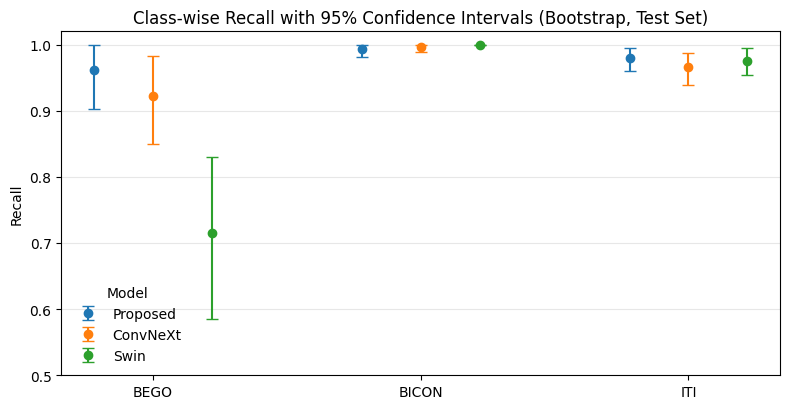

Saved figures:
 - /Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/figures/classwise_recall_ci.png
 - /Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/figures/classwise_recall_ci.pdf


In [5]:
# ===========================
# Publication-style Class-wise Recall CI Plot (ONE CELL)
# Uses: statistical_results/bootstrap_ci_metrics.csv
# ===========================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- paths ---
ROOT = Path(".").resolve()
CSV_PATH = ROOT / "statistical_results" / "bootstrap_ci_metrics.csv"
OUT_DIR = ROOT / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_PATH)

# Clean model names for figure
name_map = {
    "proposed_fusion_lr": "Proposed",
    "convnext": "ConvNeXt",
    "swin": "Swin"
}
df["model_clean"] = df["model"].map(name_map).fillna(df["model"])

# Class definitions: (label, mean, low, high)
classes = [
    ("BEGO", "recall_bego_mean", "recall_bego_ci95_low", "recall_bego_ci95_high"),
    ("BICON", "recall_bicon_mean", "recall_bicon_ci95_low", "recall_bicon_ci95_high"),
    ("ITI", "recall_iti_mean", "recall_iti_ci95_low", "recall_iti_ci95_high"),
]

models = df["model_clean"].tolist()
x = np.arange(len(classes))
width = 0.22

plt.figure(figsize=(8, 4.2))
ax = plt.gca()

for i, (_, row) in enumerate(df.iterrows()):
    means, low_err, high_err = [], [], []
    for _, m, lo, hi in classes:
        means.append(row[m])
        low_err.append(row[m] - row[lo])
        high_err.append(row[hi] - row[m])
    yerr = np.vstack([low_err, high_err])

    ax.errorbar(
        x + (i - 1) * width,
        means,
        yerr=yerr,
        fmt='o',
        capsize=4,
        label=models[i]
    )

ax.set_xticks(x)
ax.set_xticklabels([c[0] for c in classes])
ax.set_ylim(0.5, 1.02)
ax.set_ylabel("Recall")
ax.set_title("Class-wise Recall with 95% Confidence Intervals (Bootstrap, Test Set)")
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False, title="Model")

plt.tight_layout()

png_path = OUT_DIR / "classwise_recall_ci.png"
pdf_path = OUT_DIR / "classwise_recall_ci.pdf"
plt.savefig(png_path, dpi=300)
plt.savefig(pdf_path)
plt.show()

print("Saved figures:")
print(" -", png_path)
print(" -", pdf_path)


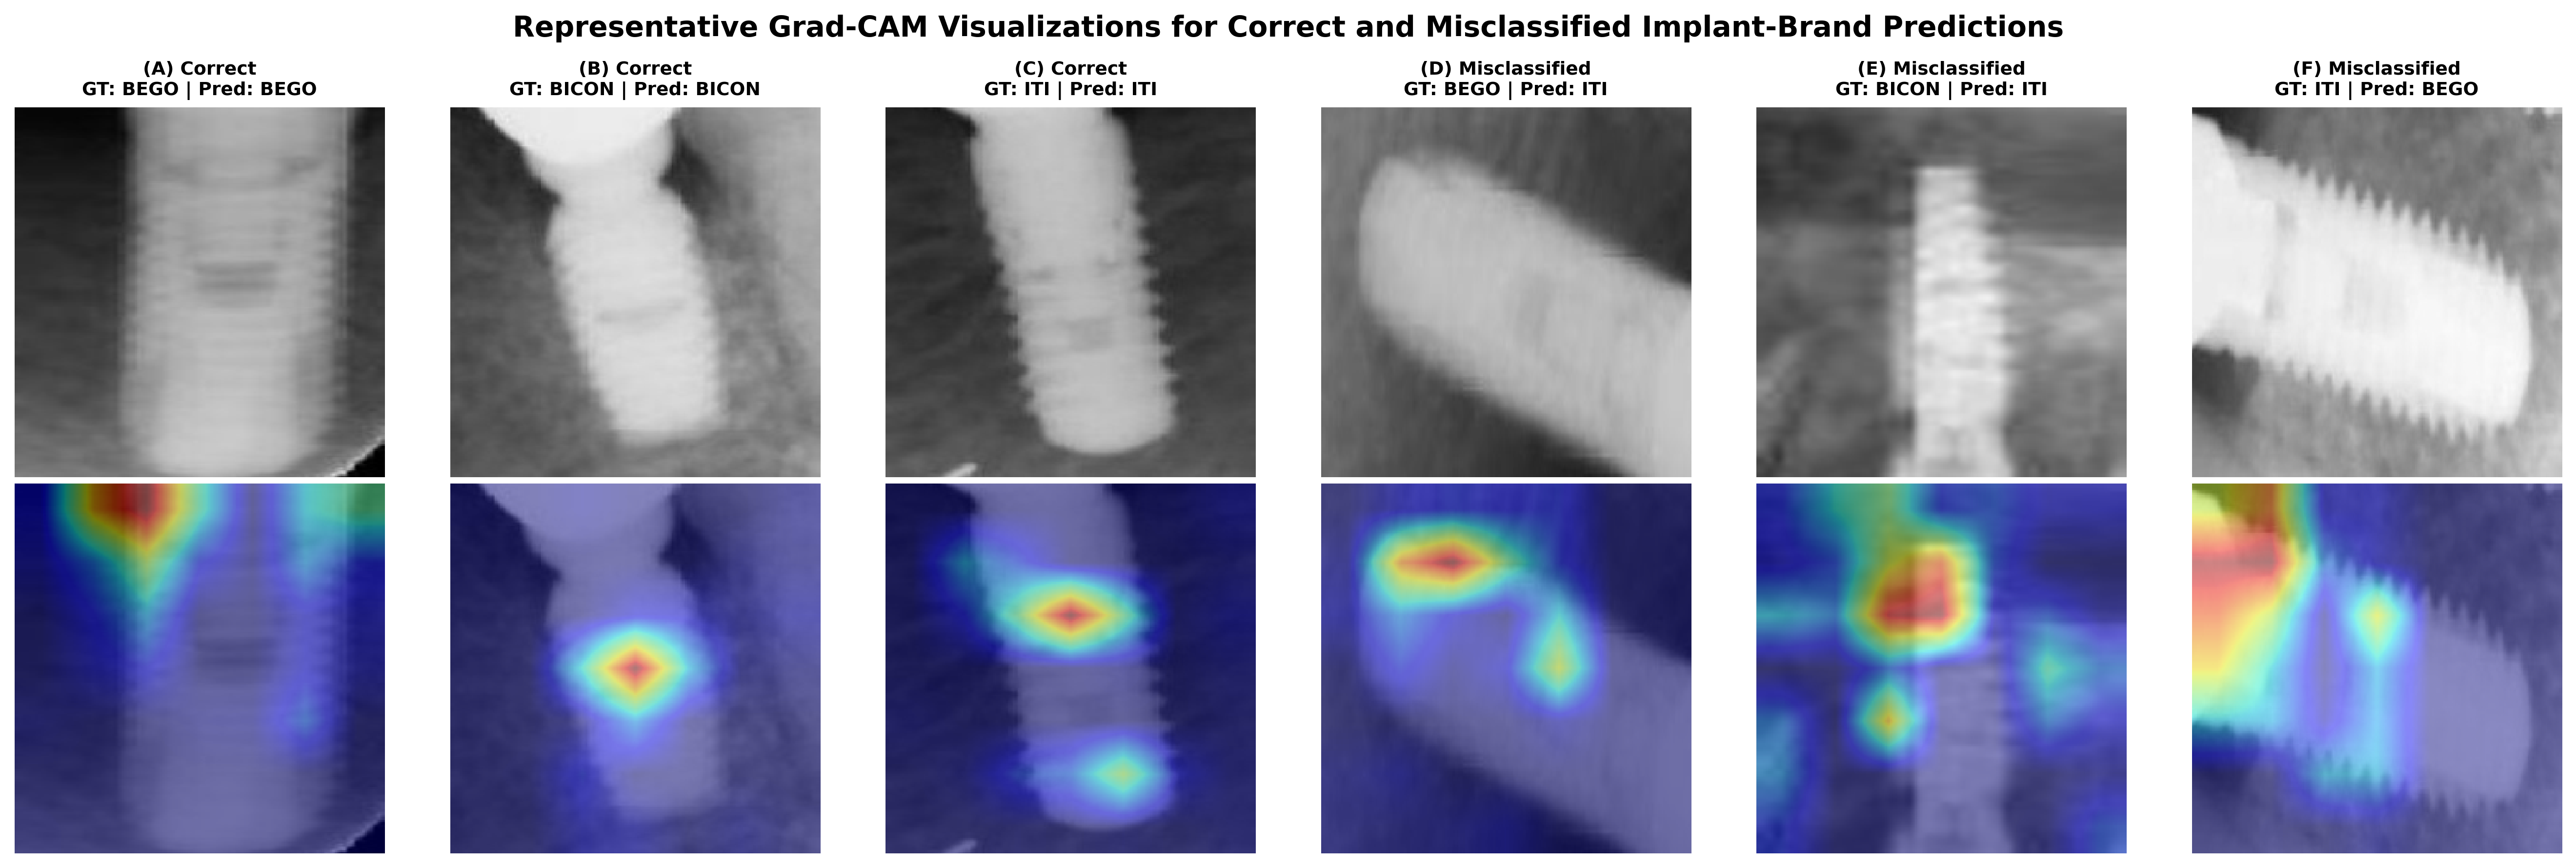

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BRANDS = ["bego", "bicon", "iti"]
NUM_CLASSES = 3

def get_model_convnext_tiny(num_classes=3):
    model = models.convnext_tiny(weights=None)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    return model.to(device)

model_path = Path("runs_grouped_80_20_convnext/models/convnext_tiny_amp_fold5_best.pt")

model = get_model_convnext_tiny(NUM_CLASSES)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

target_layer = model.features[-1][-1]

activations = {}
gradients = {}

def forward_hook(module, input, output):
    activations["value"] = output.detach()

def backward_hook(module, grad_input, grad_output):
    gradients["value"] = grad_output[0].detach()

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def generate_gradcam(image_path, class_idx):
    img = Image.open(image_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    model.zero_grad()
    logits = model(x)
    score = logits[:, class_idx]
    score.backward()

    act = activations["value"]
    grad = gradients["value"]

    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = (weights * act).sum(dim=1, keepdim=True)
    cam = F.relu(cam)

    cam = F.interpolate(cam, size=(224, 224), mode="bilinear", align_corners=False)
    cam = cam.squeeze().cpu().numpy()

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    img_resized = img.resize((224, 224))
    img_np = np.array(img_resized) / 255.0

    return img_np, cam

samples = [
    {
        "path": "/Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/roi_brands/train/bego/bego-13_jpg.rf.c5b01814469d1cff94b1cb4842166445__img411__ann681__534_304_631_586.jpg",
        "gt": "BEGO",
        "pred": "BEGO",
        "class_idx": 0,
        "status": "Correct"
    },
    {
        "path": "/Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/roi_brands/test/bicon/Bicon-174_jpg.rf.309a4caafaf75b9f0485356daf061bfd__img1__ann1__302_253_461_515.jpg",
        "gt": "BICON",
        "pred": "BICON",
        "class_idx": 1,
        "status": "Correct"
    },
    {
        "path": "/Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/roi_brands/test/iti/ITI-105_jpg.rf.035b3a8c56fef044bc7e7276bff910e8__img0__ann0__245_341_402_591.jpg",
        "gt": "ITI",
        "pred": "ITI",
        "class_idx": 2,
        "status": "Correct"
    },
    {
        "path": "/Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/roi_brands/train/bego/bego-13_jpg.rf.dd25beaa94b37ddf3ef397023fdc7b51__img1547__ann2466__111_256_407_367.jpg",
        "gt": "BEGO",
        "pred": "ITI",
        "class_idx": 2,
        "status": "Misclassified"
    },
    {
        "path": "/Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/roi_brands/train/bicon/Bicon-237_jpg.rf.f1c5f64d12e6f09ecd46a46c5f47b6c2__img1698__ann2703__403_166_445_259.jpg",
        "gt": "BICON",
        "pred": "ITI",
        "class_idx": 2,
        "status": "Misclassified"
    },
    {
        "path": "/Users/fatmanurortatas/Desktop/academic_studies/2026/implant/implant_calisma/roi_brands/train/iti/ITI-288_jpg.rf.6b6d8fe2aec9bcf71aebfdb949815280__img875__ann1377__287_398_590_571.jpg",
        "gt": "ITI",
        "pred": "BEGO",
        "class_idx": 0,
        "status": "Misclassified"
    },
]

fig, axes = plt.subplots(2, 6, figsize=(18, 6), dpi=300)

for i, sample in enumerate(samples):
    img_np, cam = generate_gradcam(sample["path"], sample["class_idx"])

    axes[0, i].imshow(img_np, cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(
        f"({chr(65+i)}) {sample['status']}\nGT: {sample['gt']} | Pred: {sample['pred']}",
        fontsize=9,
        fontweight="bold"
    )

    axes[1, i].imshow(img_np, cmap="gray")
    axes[1, i].imshow(cam, cmap="jet", alpha=0.45)
    axes[1, i].axis("off")

plt.suptitle(
    "Representative Grad-CAM Visualizations for Correct and Misclassified Implant-Brand Predictions",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("figure8_gradcam_visualizations.png", dpi=300, bbox_inches="tight")
plt.savefig("figure8_gradcam_visualizations.pdf", bbox_inches="tight")
plt.show()